In [1]:
import ast, glob, json, os, pickle, platform, time, warnings
from pathlib import Path

import hashlib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy.signal
import torch
import torch.nn as nn
import torch.nn.functional as F
import wfdb
import ast, glob, warnings
from pathlib import Path
import numpy as np, pandas as pd, wfdb
import matplotlib.pyplot as plt
import os, sys, json, pickle, warnings, random, inspect
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import scipy.signal, neurokit2 as nk, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from scipy.signal import savgol_filter
from scipy.stats import wilcoxon
from sklearn.metrics import f1_score

In [2]:

EPOCHS  = 40

BASE = Path.cwd()
LUDB_ROOT = r"../../datasets/ludb/files/ludb/1.0.1/data"
ISP_ROOT  = r"../../datasets/ispdb"
PTB_ROOT  = r"../../datasets/ptbdb"
PTB_ANN   = f"{PTB_ROOT}/ptb_qt_annotations.csv"

PW_CKPT     = r"../../PhysioWave-main/pretrainedmodels/ecg.pth"
BEATSSL_DIR = r""

CKPT    = BASE / "checkpoints"
RES_DIR = BASE / "results"
FIG_DIR = BASE / "figures"
for _d in (CKPT, RES_DIR, FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

TARGET_FS = 500
WIN_SEC   = 10.0
LEN_5000  = int(TARGET_FS * WIN_SEC)        # U-Net, BeatSSL
LEN_2048  = 2048                            # PhysioWave
TRUST     = (500, 4500)                     # 1 s discarded at each end
QT_MIN, QT_MAX, RR_MIN, RR_MAX = 200.0, 700.0, 0.30, 2.00

LABELS = {0: "none", 1: "P", 2: "QRS", 3: "T"}
COLOR  = {1: "#e8b64c", 2: "#c1121f", 3: "#2a9d8f"}
STD12  = ["i","ii","iii","avr","avl","avf","v1","v2","v3","v4","v5","v6"]

PW_ARGS = dict(in_channels=12, max_level=3, wave_kernel_size=24,
               wavelet_names=['db4','db6','sym4','coif2'], use_separate_channel=True,
               patch_size=(1, 64), embed_dim=384, depth=8, num_heads=12,
               mlp_ratio=4.0, dropout=0.1, use_pos_embed=True, pos_embed_type='2d',
               task_type='classification', num_classes=5,
               head_config={'hidden_dims':[1024], 'dropout':0.1, 'pooling':'mean'})

DEV = "cuda" if torch.cuda.is_available() else \
      ("mps" if torch.backends.mps.is_available() else "cpu")



In [3]:
# load 3 dataset
def load_ludb(root=LUDB_ROOT, lead="ii"):
    out, skipped=[],[]
    #get hea files
    for hea in sorted(glob.glob(f"{root}/*.hea")):
        p=hea[:-4] #remove ".hea" name

        try:
            rec=wfdb.rdrecord(p)

            idx=[s.lower() for s in rec.sig_name].index(lead) #find lead index
            sig=rec.p_signal[:,idx].astype(np.float32)
            ann=wfdb.rdann(p,extension=lead) #raw

            #mask
            samples=ann.sample
            # print(len(sig))
            mask=np.zeros(len(sig),int)
            y=list(ann.symbol)
            i=0
            while i<len(y):
                if y[i]=="(" and i+2<len(y) and y[i+2]==")":
                    cls={"p":1,"N":2,"t":3}.get(y[i+1])
                    if cls:
                        mask[samples[i]:samples[i+2]+1]=cls
                        # print(samples[i])
                        # print(samples[i+2])
                        # print(mask[samples[i]:samples[i+2]])
                    i+=3
                else:
                    i+=1
                # print(mask)


            out.append({
                "id": f"ludb_{Path(p).name}",
                "path":p,
                "fs":int(rec.fs),
                "sig":sig,
                "sig12": rec.p_signal.astype(np.float32),
                "mask":mask,
                "ann":ann, #raw wfdb triples
                "leads":[s.lower() for s in rec.sig_name]
            })

        except Exception as e:
            skipped.append(f"{p} has problem as {e}")

    print(f"skipped: {len(skipped)}")
    print(f"loaded: {len(out)}")

    # for s in skipped: print("       ",s)
    return out

ISPMask={0:1,1:2,2:3}

def load_isp(root=ISP_ROOT,which="test",lead="ii"):
    csv=pd.read_csv(f"{root}/{which}_isp_delineation_data.csv")
    ann_col=next((c for c in csv.columns if str(csv[c].iloc[0]).strip().startswith("[(")),csv.columns[-1])
    out, skipped=[],[]

    for data,r in csv.iterrows():
        rid=str(r["file_name"])
        p=f"{root}/{which}_data/{rid}"
        # print(p)
        try:
            rec=wfdb.rdrecord(p)
            idx=[s.lower() for s in rec.sig_name].index(lead)
            sig=rec.p_signal.astype(np.float32)
            if np.nanmax(np.abs(sig))>50:
                sig=sig/1000.0
            # ann=wfdb.rdann(p,extension=lead)
            waves=ast.literal_eval(r[ann_col])
#             Evaluate an expression node or a string containing only a Python expression.

            #mask
            mask=np.zeros(len(sig),int)
            for cls, on ,off in waves:
                m=ISPMask.get(cls)
                if m:
                    mask[on:min(off+1,len(sig))] = m
                    # print(cls,on,off)
                    # print(mask[on])
                    # print(mask[off+1])
                    # print(mask[on:min(off+1,len(sig))])

            out.append({
                "id": f"ispdb_{Path(p).name}",
                "path":p,
                "fs":int(rec.fs),
                "sig":rec.p_signal[:,idx].astype(np.float32),
                "sig12": sig,
                "mask":mask,
                "waves":waves, #diff from ludb; raw(class,on,off)tuples
                "leads":[s.lower() for s in rec.sig_name]
            })

        except Exception as e:
            skipped.append(f"{p} has problem as {e}")

    print(f"skipped: {len(skipped)}")
    print(f"loaded: {len(out)}")

    for s in skipped: print("       ",s)
    return out

COLS  = ["patient","record","q1","q2","q3","q4","q5","q_med",
         "t1","t2","t3","t4","t5","t_med"]
QCOLS = ["q1","q2","q3","q4","q5"]
TCOLS = ["t1","t2","t3","t4","t5"]
NUM=COLS[2:]


def ptb_annotations():
    """The five reader marks per record, from the CSV alone. No waveforms."""
    csv = pd.read_csv(PTB_ANN, header=None, dtype=str)
    csv.columns = COLS
    for c in NUM:
        csv[c] = pd.to_numeric(
            csv[c].astype(str).str.replace(r"[^\d.\-]", "", regex=True),
            errors="coerce")
    ann = csv[csv[NUM].notna().sum(axis=1) >= 10].copy()
    ann["record"] = ann["record"].astype(str).str.strip()
    return ann


def ptb_reader_agreement(verbose=True):
    """Median standard deviation across five readers, in milliseconds.
    """
    ann = ptb_annotations()
    q  = ann[QCOLS].to_numpy(float)
    t  = ann[TCOLS].to_numpy(float)
    qt = t - q
    sd_q, sd_t, sd_qt = (np.nanstd(x, axis=1, ddof=1) for x in (q, t, qt))
    out = {"n": len(ann),
           "qrs_onset_sd": float(np.nanmedian(sd_q)),
           "t_offset_sd":  float(np.nanmedian(sd_t)),
           "qt_sd":        float(np.nanmedian(sd_qt))}
    if verbose:
        print(f"  records with five reader marks: {out['n']}")
        print(f"  QRS onset   median SD {out['qrs_onset_sd']:5.2f} ms")
        print(f"  T offset    median SD {out['t_offset_sd']:5.2f} ms")
        print(f"  QT interval median SD {out['qt_sd']:5.2f} ms   <- the floor")
    return out


def load_ptb(root=PTB_ROOT, lead="ii", verbose=True):
    """PTB records with the median reader marks attached.
    """
    ann = ptb_annotations()

    lookup = {}                                   # built ONCE, outside the loop
    for h in sorted(glob.glob(f"{root}/**/*.hea", recursive=True)):
        lookup[Path(h).stem] = h[:-4]
    if verbose:
        print(f"  header files found: {len(lookup)}")

    norm = lambda s: str(s).strip().lower().replace("_", "").replace("-", "")
    lookup_n = {norm(k): v for k, v in lookup.items()}
    ann["rec_path"] = ann["record"].map(lambda s: lookup_n.get(norm(s)))
    matched = ann.dropna(subset=["rec_path"]).reset_index(drop=True)
    if verbose:
        print(f"  annotation rows matched to a file: {len(matched)} of {len(ann)}")

    out, skipped = [], []
    for _, r in matched.iterrows():
        pth = str(r["rec_path"])
        try:
            rec = wfdb.rdrecord(pth)
            names = [s.lower() for s in rec.sig_name]
            if lead not in names:
                skipped.append(f"{pth}: no lead {lead}"); continue
            sig = np.asarray(rec.p_signal[:, names.index(lead)], dtype=np.float32)

            # float arrays, not generators
            q = np.array([r[c] for c in QCOLS], dtype=float)
            t = np.array([r[c] for c in TCOLS], dtype=float)
            ok = np.isfinite(q) & np.isfinite(t) & (t > q)
            if ok.sum() < 2:
                skipped.append(f"{pth}: fewer than two usable reader marks"); continue

            out.append({
                "id":    f"ptbdb_{Path(pth).name}",
                "path":  pth,
                "fs":    int(rec.fs),
                "sig":   sig,
                "sig12": np.asarray(rec.p_signal, dtype=np.float32),
                "q_ref": float(np.median(q[ok])),   # gt_fiducials reads these
                "t_ref": float(np.median(t[ok])),
                "sd_qt": float(np.nanstd((t - q)[ok], ddof=1)),
                "leads": names,
            })
        except Exception as e:
            skipped.append(f"{pth}: {type(e).__name__}: {e}")

    if verbose:
        print(f"  loaded {len(out)}, skipped {len(skipped)}")
    return out



In [4]:
#load encoders
sys.modules.pop("model", None)

sys.path.append("../../qtcnet-main")
from inception_model import ECGModel
# sys.path.insert(0, "../PhysioWave-main")

sys.path.append("../../PhysioWave-main")
from model import BERTWaveletTransformer      # noqa
sys.path.append("../../beat_ssl")
from src.models.backbone.resnet import resnet1d18, resnet1d50
from src.models.decoder import ResNet1DDecoder

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

def pick_device(override=None):
    if override: return override
    if torch.backends.mps.is_available(): return "mps"
    # if torch.cuda.is_available(): return "cuda"
    return "cpu"


In [5]:
## QTcNet

sys.path.append("../../qtcnet-main")
from inception_model import ECGModel

QTCNET_LEADS = ["i","ii","iii","avr","avf","avl","v1","v2","v3","v4","v5","v6"]
_QTCNET = None

def load_qtcnet():
    global _QTCNET
    if _QTCNET is None:
        w = glob.glob("../../qtcnet-main/**/best_model.pth.tar", recursive=True)[0]
        m = ECGModel(c_in=12, c_out=1)
        ck = torch.load(w, map_location="mps")
        for k in ("state_dict","model_state_dict","model","net"):
            if isinstance(ck, dict) and k in ck: ck = ck[k]; break
        ck = {("model."+k if not k.startswith("model.") else k): v for k, v in ck.items()}
        m.load_state_dict(ck, strict=True); m.eval()
        _QTCNET = m
        print(f"QTcNet loaded from {w}")
    return _QTCNET

def predict_qtcnet(rec):
    idx = [rec["leads"].index(l) for l in QTCNET_LEADS]
    s = np.nan_to_num(np.asarray(rec["sig12"], float)[:, idx])
    if rec["fs"] != 100:
        s = scipy.signal.resample(s, int(len(s)*100/rec["fs"]), axis=0)
    if s.shape[0] < 1000:
        s = np.pad(s, ((0, 1000-s.shape[0]), (0, 0)))
    with torch.no_grad():
        x = torch.tensor(s[:1000].T, dtype=torch.float32).unsqueeze(0)
        return float(load_qtcnet()(x).squeeze())

def predict_wavelet(rec, method="dwt"):
    """NeuroKit dwt or cwt -> (onsets, offsets, rpeaks)."""
    fs  = rec["fs"]
    sig = np.asarray(rec["sig"], float)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clean = nk.ecg_clean(sig, sampling_rate=fs)
        _, info = nk.ecg_peaks(clean, sampling_rate=fs)
        rp = info["ECG_R_Peaks"]                     # <-- leave as integers
        if len(rp) < 4:
            return np.array([]), np.array([]), np.asarray(rp, float)
        _, w = nk.ecg_delineate(clean, rp, sampling_rate=fs, method=method)

    on  = np.sort(np.asarray(w["ECG_R_Onsets"],  float)[
                  np.isfinite(np.asarray(w["ECG_R_Onsets"],  float))])
    off = np.sort(np.asarray(w["ECG_T_Offsets"], float)[
                  np.isfinite(np.asarray(w["ECG_T_Offsets"], float))])

    ons, offs = [], []
    for o in on:
        cand = off[(off > o) & (off - o < 0.7*fs)]
        if len(cand):
            ons.append(o); offs.append(cand[0])
    return np.asarray(ons, float), np.asarray(offs, float), np.asarray(rp, float)


In [6]:
FORMULAE = {
    "bazett":     lambda qt, rr: qt / np.sqrt(rr),
    "fridericia": lambda qt, rr: qt / np.cbrt(rr),
    "framingham": lambda qt, rr: qt + 154*(1 - rr),
    "hodges":     lambda qt, rr: qt + 1.75*(60/rr - 60),
    "rautaharju": lambda qt, rr: qt * (120 + 60/rr) / 180,
}

def gt_fiducials(rec):
    """(qrs_onsets, t_offsets) in samples, one pair per beat."""
    if "ann" in rec:                                   # LUDB: ( p ) ( N ) ( t )
        s, y = np.asarray(rec["ann"].sample), list(rec["ann"].symbol)
        on, off = [], []
        for i, sym in enumerate(y):
            if sym != "N": continue
            j = i - 1
            while j >= 0 and y[j] != "(": j -= 1
            k = i + 1
            while k < len(y) and y[k] != "t": k += 1
            if j < 0 or k >= len(y): continue
            m = k + 1
            while m < len(y) and y[m] != ")": m += 1
            if m >= len(y): continue
            on.append(s[j]); off.append(s[m])
        return np.asarray(on, float), np.asarray(off, float)
    if "waves" in rec:                                 # ISP: (class, on, off)
        w = rec["waves"]; on, off = [], []
        for i, (cls, o, _) in enumerate(w):
            if cls != 1: continue                      # 1 = QRS
            nxt = [b for c2, _, b in w[i+1:] if c2 == 2]   # 2 = T
            if nxt: on.append(o); off.append(nxt[0])
        return np.asarray(on, float), np.asarray(off, float)
    if "q_ref" in rec and "t_ref" in rec:              # PTB: one beat
        return np.array([rec["q_ref"]], float), np.array([rec["t_ref"]], float)
    raise KeyError(f"{rec.get('id','?')}: no annotation (keys {sorted(rec)})")


def r_peaks(rec):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clean = nk.ecg_clean(np.asarray(rec["sig"], float), sampling_rate=rec["fs"])
        _, info = nk.ecg_peaks(clean, sampling_rate=rec["fs"])
    return np.asarray(info["ECG_R_Peaks"], float)


def assign_rr(onsets, rpeaks, fs):
    """RR interval immediately preceding each beat, in seconds."""
    rr = np.full(len(onsets), np.nan)
    if len(rpeaks) < 2: return rr
    ri = np.diff(rpeaks) / fs
    for k, o in enumerate(onsets):
        j = np.searchsorted(rpeaks, o)
        if 1 <= j <= len(ri): rr[k] = ri[j-1]
    return rr

# ---- notebook cell 12 --------------------------------------------------
def qtc(onsets, offsets, rpeaks, fs, formula="bazett", min_beats=2):
    n = min(len(onsets), len(offsets))
    if n == 0: return np.nan
    qt = (np.asarray(offsets)[:n] - np.asarray(onsets)[:n]) / fs * 1000
    rr = assign_rr(np.asarray(onsets)[:n], rpeaks, fs)
    if not np.isfinite(rr).any() and len(rpeaks) > 1:
        rr = np.full(n, np.median(np.diff(rpeaks) / fs))
    ok = (np.isfinite(qt) & np.isfinite(rr) & (qt >= QT_MIN) & (qt <= QT_MAX)
          & (rr >= RR_MIN) & (rr <= RR_MAX))
    if ok.sum() < min_beats: return np.nan
    return float(np.median(FORMULAE[formula](qt[ok], rr[ok])))


def match(gt, pred, fs, tol_ms=150):
    """Greedy nearest-unused matching. Returns (errors in ms, tp, fn).
    """
    gt, pred = np.asarray(gt, float), np.asarray(pred, float)
    if len(gt) == 0:   return [], 0, 0
    if len(pred) == 0: return [], 0, len(gt)
    tol = tol_ms * fs / 1000.0
    errs, used = [], set()
    for g in gt:
        cand = [(abs(p - g), j) for j, p in enumerate(pred) if j not in used]
        if not cand: break
        d, j = min(cand)
        if d <= tol:
            used.add(j); errs.append((pred[j] - g) / fs * 1000)
    return errs, len(errs), len(gt) - len(errs)


In [7]:
# T-offset refinement
def _baseline(sig, t_off_init, fs, lo_ms=60, hi_ms=160):
    a = int(t_off_init + lo_ms*fs/1000); b = int(t_off_init + hi_ms*fs/1000)
    a, b = max(0, min(a, len(sig)-1)), max(1, min(b, len(sig)))
    return float(np.median(sig)) if b-a < 3 else float(np.median(sig[a:b]))

def _t_peak(sig, qrs_off, t_off_init, base):
    a, b = int(qrs_off), int(t_off_init)
    if b - a < 5: return None, 0
    seg = sig[a:b] - base
    k = int(np.argmax(np.abs(seg)))
    return a + k, (1 if seg[k] >= 0 else -1)

def _smooth(x, fs):
    w = int(round(0.020*fs)) | 1
    w = max(5, min(w, len(x)-1 if len(x) % 2 == 0 else len(x)-2))
    return savgol_filter(x, w, 3) if len(x) > w else np.asarray(x, float)

def t_end_tangent(sig, t_peak, base, pol, fs, search_ms=120):
    """Steepest point on the falling limb, tangent extended to baseline."""
    y = pol*(np.asarray(sig, float) - base)
    a = int(t_peak) + 1; b = min(len(y)-1, int(t_peak + search_ms*fs/1000))
    if b - a < 5: return None
    ys = _smooth(y[a:b+1], fs); d = np.gradient(ys)
    k = int(np.argmin(d))
    if d[k] >= -1e-9: return None
    return float(a + k - ys[k]/d[k])

# ---- notebook cell 13 --------------------------------------------------
def t_end_knee(sig, t_peak, base, pol, fs, search_ms=200):
    """Point furthest from the chord joining T peak to end of search window."""
    y = pol*(np.asarray(sig, float) - base)
    a = int(t_peak); b = min(len(y)-1, int(t_peak + search_ms*fs/1000))
    if b - a < 8: return None
    ys = _smooth(y[a:b+1], fs); x = np.arange(len(ys), dtype=float)
    dx, dy = x[-1]-x[0], ys[-1]-ys[0]
    den = np.hypot(dx, dy)
    if den < 1e-9: return None
    dist = ((x-x[0])*dy - (ys-ys[0])*dx)/den
    return float(a + int(np.argmax(dist)))

def refine_t_offset(sig, qrs_off, t_off_init, fs, max_shift_ms=30, mode="both"):
    sig = np.asarray(sig, float)
    t0 = int(np.clip(t_off_init, 1, len(sig)-2))
    base = _baseline(sig, t0, fs)
    pk, pol = _t_peak(sig, qrs_off, t0, base)
    if pk is None: return float(t0)
    cands = []
    if mode in ("tangent", "both"):
        c = t_end_tangent(sig, pk, base, pol, fs)
        if c is not None: cands.append(c)
    if mode in ("knee", "both"):
        c = t_end_knee(sig, pk, base, pol, fs)
        if c is not None: cands.append(c)
    if not cands: return float(t0)
    lim = max_shift_ms*fs/1000.0
    return float(np.clip(float(np.mean(cands)), t0-lim, t0+lim))

def apply_refinement(sig, ons, offs, fs, mode="both", max_shift_ms=30):
    if len(offs) == 0: return ons, offs
    qrs_dur = int(round(0.10*fs))                # QRS onset + 100 ms ~ QRS end
    out = []
    for k, t_off in enumerate(offs):
        r = refine_t_offset(sig, float(ons[k]) + qrs_dur, float(t_off),
                            fs, max_shift_ms, mode)
        out.append(r if r is not None and np.isfinite(r) else t_off)
    return ons, np.asarray(out, float)

In [8]:
def runs_of(mask, c, lo=0, hi=None):
    hi = hi or len(mask)
    seg = np.zeros(len(mask), int); seg[lo:hi] = (np.asarray(mask)[lo:hi] == c)
    e = np.diff(np.concatenate([[0], seg, [0]]))
    return [(s, t-1) for s, t in zip(np.where(e == 1)[0], np.where(e == -1)[0])
            if t-1-s >= 2]

def _prep(rec, target, leads):
    """leads: 12 or 1 (lead II). Returns (C, target) float32, z-scored."""
    s = np.nan_to_num(np.asarray(rec["sig12"], np.float32))[:, :12]
    if s.shape[0] != target:
        s = scipy.signal.resample(s, target, axis=0)
    s = (s - s.mean(0)) / (s.std(0) + 1e-6)
    s = s.T
    return s.astype(np.float32) if leads == 12 else s[1:2].astype(np.float32)

def _prep_mask(rec, target):
    m = np.asarray(rec["mask"], int)
    if len(m) != target:
        m = m[np.linspace(0, len(m)-1, target).round().astype(int)]
    return m

class SegDS(Dataset):
    def __init__(self, recs, leads=12, target=LEN_5000):
        self.items = [(torch.tensor(_prep(r, target, leads)),
                       torch.tensor(_prep_mask(r, target), dtype=torch.long))
                      for r in recs]
    def __len__(self): return len(self.items)
    def __getitem__(self, i): return self.items[i]

In [9]:
#prepare dataset for each method
SegDS1L = lambda recs: SegDS(recs,  1, LEN_5000)
SegDS12 = lambda recs: SegDS(recs, 12, LEN_5000)
SegDSPW = lambda recs: SegDS(recs, 12, LEN_2048) #

In [10]:
class UNet1D(nn.Module):
    """[B, 1, 5000] -> [B, 4, 5000]. Trained from scratch on ISP."""
    def __init__(self, ch=16, n_cls=4):
        super().__init__()
        def blk(i, o):
            return nn.Sequential(nn.Conv1d(i, o, 7, padding=3), nn.BatchNorm1d(o), nn.ReLU(),
                                 nn.Conv1d(o, o, 7, padding=3), nn.BatchNorm1d(o), nn.ReLU())
        self.e1, self.e2, self.e3 = blk(1, ch), blk(ch, ch*2), blk(ch*2, ch*4)
        self.pool = nn.MaxPool1d(2); self.b = blk(ch*4, ch*8)
        self.u3, self.d3 = nn.ConvTranspose1d(ch*8, ch*4, 2, 2), blk(ch*8, ch*4)
        self.u2, self.d2 = nn.ConvTranspose1d(ch*4, ch*2, 2, 2), blk(ch*4, ch*2)
        self.u1, self.d1 = nn.ConvTranspose1d(ch*2, ch,   2, 2), blk(ch*2, ch)
        self.out = nn.Conv1d(ch, n_cls, 1)
    def forward(self, x):
        L = x.shape[-1]; pad = (8 - L % 8) % 8
        if pad: x = F.pad(x, (0, pad))
        e1 = self.e1(x); e2 = self.e2(self.pool(e1)); e3 = self.e3(self.pool(e2))
        b  = self.b(self.pool(e3))
        d3 = self.d3(torch.cat([self.u3(b),  e3], 1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], 1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], 1))
        return self.out(d1)[:, :, :L]

In [11]:
class BeatSSLSeg(nn.Module):
    """[B, 12, 5000] -> [B, 4, 5000]. Frozen pretrained encoder, decoder on ISP."""
    def __init__(self, pre_enc_dir=None, n_cls=4, freeze_encoder=True, verbose=False):
        super().__init__()
        self.encoder = resnet1d18(num_classes=128, input_channels=12)
        self.decoder = ResNet1DDecoder(output_channels=n_cls)
        self.freeze_encoder = freeze_encoder
        d = pre_enc_dir or BEATSSL_DIR
        sd = torch.load(Path(d).resolve()/"ecg_encoder_model.pth",
                        map_location="cpu", weights_only=False)
        for k in ("state_dict", "model_state_dict", "model"):
            if isinstance(sd, dict) and k in sd and isinstance(sd[k], dict):
                sd = sd[k]; break
        enc = {k[len("encoder."):]: v for k, v in sd.items()
               if k.startswith("encoder.")} or dict(sd)
        before = {k: v.clone() for k, v in self.encoder.state_dict().items()}
        self.encoder.load_state_dict(enc, strict=False)
        changed = sum(1 for k in before
                      if not torch.equal(before[k], self.encoder.state_dict()[k]))
        assert changed > 0, "BeatSSL encoder did not load — checkpoint is wrong"
        if verbose: print(f"  BeatSSL: {changed}/{len(before)} tensors loaded")
        if freeze_encoder:
            for p in self.encoder.parameters(): p.requires_grad = False
    def train(self, mode=True):
        super().train(mode)
        if self.freeze_encoder: self.encoder.eval()
        return self
    def forward(self, x):
        if self.freeze_encoder:
            with torch.no_grad(): _, e = self.encoder(x)
        else:
            _, e = self.encoder(x)
        return self.decoder(e)[:, :, :LEN_5000]


In [12]:
class PhysioWaveSeg(nn.Module):
    """[B, 12, 2048] -> [B, 4, 2048]. Pools FREQUENCY, keeps the time axis."""
    def __init__(self, ckpt=None, n_cls=4, freeze_encoder=True, verbose=False):
        super().__init__()
        self.encoder = BERTWaveletTransformer(**PW_ARGS)
        # ck = torch.load(ckpt or PW_CKPT, map_location="cuda", weights_only=False)
        ck = torch.load(ckpt or PW_CKPT, map_location="cpu", weights_only=False)
        sd = ck["model_state_dict"] if "model_state_dict" in ck else ck

        miss, unexp = self.encoder.load_state_dict(sd, strict=False)
        enc_miss = [k for k in miss if not k.startswith(("task_heads", "head"))]
        assert not enc_miss, f"PhysioWave weights missing: {enc_miss[:5]}"
        self.fp, self.tp, self.D = 48, 32, 384
        self.freeze_encoder = freeze_encoder
        if freeze_encoder:
            for p in self.encoder.parameters(): p.requires_grad = False
        def up(i, o):
            return nn.Sequential(nn.ConvTranspose1d(i, o, 4, stride=2, padding=1),
                                 nn.BatchNorm1d(o), nn.GELU())
        self.dec = nn.Sequential(up(384,256), up(256,192), up(192,128),
                                 up(128,96), up(96,64), up(64,32),
                                 nn.Conv1d(32, n_cls, 3, padding=1))
    def train(self, mode=True):
        super().train(mode)
        if self.freeze_encoder: self.encoder.eval()
        return self
    def forward(self, x):
        if self.freeze_encoder:
            with torch.no_grad(): f = self.encoder.forward_features(x)
        else:
            f = self.encoder.forward_features(x)
        B, N, D = f.shape
        f = f.view(B, self.fp, self.tp, D).mean(1).permute(0, 2, 1)
        return self.dec(f)[:, :, :LEN_2048]


In [13]:
# training for decoder
def train_seg(build, train_ds, val_ds, *, name, seed=42, epochs=40, lr=1e-3,
              batch=16, patience=10, device=None, verbose=True):

    set_seed(seed)
    dev = pick_device(device)
    model = build().to(dev)

    with torch.no_grad():
        x0, _ = train_ds[0]
        model(x0.unsqueeze(0).to(dev))

    params = [p for p in model.parameters() if p.requires_grad]
    opt    = torch.optim.Adam(params, lr=lr)
    lossf  = nn.CrossEntropyLoss()
    tl = DataLoader(train_ds, batch_size=batch, shuffle=True)
    vl = DataLoader(val_ds,   batch_size=batch)

    hist = {"train_loss": [], "val_loss": [], "val_f1": []}
    best, best_ep, bad = -1.0, 0, 0
    path = CKPT / f"{name}_s{seed}.pt"
    print(f"{name} | seed {seed} | {dev} | lr {lr:.2g} | batch {batch} | "
          f"{sum(p.numel() for p in params)/1e6:.2f} M trainable | "
          f"train {len(train_ds)} val {len(val_ds)}")

    for ep in range(1, epochs+1):
        model.train(); tot = n = 0
        for x, y in tl:
            x, y = x.to(dev), y.to(dev)
            opt.zero_grad()
            out = model(x)
            L = min(out.shape[-1], y.shape[-1])
            loss = lossf(out[:, :, :L], y[:, :L])
            loss.backward(); opt.step()
            tot += loss.item()*len(x); n += len(x)
        tr_loss = tot/max(n, 1)

        model.eval(); vt = vn = 0; P, T = [], []
        with torch.no_grad():
            for x, y in vl:
                x, y = x.to(dev), y.to(dev)
                out = model(x)
                L = min(out.shape[-1], y.shape[-1])
                vt += lossf(out[:, :, :L], y[:, :L]).item()*len(x); vn += len(x)
                P.append(out[:, :, :L].argmax(1).cpu().numpy().ravel()) ##sswww
                T.append(y[:, :L].cpu().numpy().ravel())
        va_loss = vt/max(vn, 1)
        f1 = f1_score(np.concatenate(T), np.concatenate(P),
                      average="macro", labels=[1, 2, 3], zero_division=0)

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["val_f1"].append(f1)

        if f1 > best:
            best, best_ep, bad = f1, ep, 0
            torch.save(model.state_dict(), path)
        else:
            bad += 1
        if verbose and (ep == 1 or ep % 5 == 0):
            print(f"  ep {ep:3d}: train {tr_loss:.4f} | val {va_loss:.4f} | F1 {f1:.4f}")
        if bad >= patience: #no early stop... due to running full epoch
            print(f"  early stop at ep {ep} (no gain for {patience})")
            break

    model.load_state_dict(torch.load(path, map_location=dev))
    print(f"  -> best F1 {best:.4f} @ epoch {best_ep} confirming\n")
    return model, hist


In [14]:

def _mask_to_fiducials(lab, fs_eff, trust):
    lo, hi = trust
    qrs, t = runs_of(lab, 2, lo, hi), runs_of(lab, 3, lo, hi)
    ons, offs = [], []
    for qon, _ in qrs:
        cand = [b for a, b in t if a > qon and (b - qon) < 0.7*fs_eff]
        if cand: ons.append(qon); offs.append(cand[0])
    return np.asarray(ons, float), np.asarray(offs, float)

def _predict_mask(rec, model, target, leads):
    dev = next(model.parameters()).device
    x = torch.tensor(_prep(rec, target, leads)).unsqueeze(0).to(dev)
    model.eval()
    with torch.no_grad():
        return model(x).argmax(1)[0].cpu().numpy()

def predict_unet(rec, model):
    lab = _predict_mask(rec, model, LEN_5000, 1)
    fs_eff = LEN_5000/(len(rec["sig"])/rec["fs"])
    on, off = _mask_to_fiducials(lab, fs_eff, TRUST)
    s = len(rec["sig"])/LEN_5000
    return on*s, off*s, lab

def predict_beatssl(rec, model):
    lab = _predict_mask(rec, model, LEN_5000, 12)
    fs_eff = LEN_5000/(len(rec["sig"])/rec["fs"])
    on, off = _mask_to_fiducials(lab, fs_eff, TRUST)
    s = len(rec["sig"])/LEN_5000
    return on*s, off*s, lab

def predict_physiowave(rec, model):
    lab = _predict_mask(rec, model, LEN_2048, 12)
    fs_eff = LEN_2048/(len(rec["sig"])/rec["fs"])
    tr = (int(TRUST[0]*LEN_2048/LEN_5000), int(TRUST[1]*LEN_2048/LEN_5000))
    on, off = _mask_to_fiducials(lab, fs_eff, tr)
    s = len(rec["sig"])/LEN_2048
    return on*s, off*s, lab

SEG_PRED = {"unet": predict_unet, "beatssl": predict_beatssl,
            "physiowave": predict_physiowave}

In [15]:
def predict_seg_any(rec, method, models, refine=None, max_shift_ms=30):
    fs, sig = rec["fs"], np.asarray(rec["sig"], float)
    if method in ("dwt", "cwt"):
        return predict_wavelet(rec, method)          # baselines never refined
    on, off, _ = SEG_PRED[method](rec, models[method])
    rp = r_peaks(rec)
    if refine:
        on, off = apply_refinement(sig, on, off, fs, refine, max_shift_ms)
    return on, off, rp


#evaluation based on QTc Scale table
def evaluate_seg(recs, models, *, name, refine=None, max_shift_ms=30,
                 methods=("dwt", "cwt", "unet", "beatssl", "physiowave"),
                 include_qtcnet=True, formula="bazett",
                 tol_on=6.5, tol_off=30.6, quiet=True):
    """-> (fiducial table, QTc table, per-record frame)"""
    fid  = {m: {"on": [], "off": [], "tp": 0, "fn": 0} for m in methods}
    rows, seen = [], set()

    for rec in recs:
        fs = rec["fs"]
        try:
            gt_on, gt_off = gt_fiducials(rec)
        except Exception:
            continue
        if len(gt_on) == 0: continue
        gt = qtc(gt_on, gt_off, r_peaks(rec), fs, formula)
        if not np.isfinite(gt): continue

        row = {"dataset": name, "id": rec["id"], "gt": gt,
               "sex": rec.get("sex"), "hr": rec.get("hr", np.nan)}

        for m in methods:
            if m in SEG_PRED and m not in models:
                row[m] = np.nan; continue
            try:
                on, off, rp = predict_seg_any(rec, m, models, refine, max_shift_ms)
                row[m] = qtc(on, off, rp, fs, formula)
            except Exception as e:
                if m not in seen and not quiet:
                    print(f"  {m}: {type(e).__name__}: {e}"); seen.add(m)
                on = off = np.array([]); row[m] = np.nan
            e1, tp1, fn1 = match(gt_on,  on,  fs, tol_ms=150)
            e2, tp2, fn2 = match(gt_off, off, fs, tol_ms=150)
            fid[m]["on"].extend(e1); fid[m]["off"].extend(e2)
            fid[m]["tp"] += tp1 + tp2; fid[m]["fn"] += fn1 + fn2

        if include_qtcnet:
            try:    row["qtcnet"] = predict_qtcnet(rec)
            except Exception: row["qtcnet"] = np.nan
        rows.append(row)

    f_rows = []
    for m, r in fid.items():
        for pt, errs, tol in [("QRS onset", r["on"], tol_on),
                              ("T offset",  r["off"], tol_off)]:
            e = np.asarray(errs, float)
            if e.size == 0: continue
            f_rows.append({"dataset": name, "refine": refine or "none", "method": m,
                           "point": pt, "n": int(e.size), "bias": e.mean(),
                           "SD": e.std(ddof=1) if e.size > 1 else 0.0,
                           "MAE": np.abs(e).mean(),
                           "within_tol_%": 100*np.mean(np.abs(e) <= tol),
                           "sensitivity_%": (100*r["tp"]/(r["tp"]+r["fn"])
                                             if r["tp"]+r["fn"] else 0.0)})
    fdf = pd.DataFrame(f_rows).round(2)

    df = pd.DataFrame(rows)
    all_m = list(methods) + (["qtcnet"] if include_qtcnet else [])
    q_rows = []
    for m in all_m:
        if m not in df.columns: continue
        d = df[[m, "gt"]].dropna()
        if len(d) < 3: continue
        e = (d[m] - d["gt"]).values
        q_rows.append({"dataset": name, "refine": refine or "none", "method": m,
                       "n": len(d), "coverage_%": 100*len(d)/len(df),
                       "bias": e.mean(), "SD": e.std(ddof=1),
                       "MAE": np.abs(e).mean(),
                       "median_AE": float(np.median(np.abs(e))),
                       "p90_AE": float(np.percentile(np.abs(e), 90)),
                       "corr": float(np.corrcoef(d[m], d["gt"])[0, 1]),
                       "IEC": ("PASS" if abs(e.mean()) <= 25 and e.std(ddof=1) <= 30
                               else "FAIL")})
    qdf = pd.DataFrame(q_rows).sort_values("MAE").round(2) if q_rows else pd.DataFrame()

    print(f"[{name}] {len(df)} records | " +
          " | ".join(f"{m} {int(df[m].notna().sum())}"
                     for m in ["gt"] + all_m if m in df))
    return fdf, qdf, df



In [16]:
ludb=load_ludb()
print(f"LUDB {len(ludb)} records")
isp=load_isp(which="train")+load_isp(which="test") #load train and test folders
print(f"ISPdeli {len(isp)} records")

print("\nPTB reader agreement, from the annotation CSV only:")
try:
    AGREE     = ptb_reader_agreement()
    FLOOR_SD  = AGREE["qt_sd"]
    FLOOR_MAE = FLOOR_SD*np.sqrt(2/np.pi)
    print(f"  FLOOR_SD  {FLOOR_SD:.2f} ms   FLOOR_MAE {FLOOR_MAE:.2f} ms")
except Exception as _e:
    print(f"  not computed ({_e}); keeping FLOOR_SD = {FLOOR_SD}")
try:
    ptb = load_ptb()
except Exception as _e:
    ptb = []; print(f"  not loaded ({type(_e).__name__}: {_e})")

skipped: 0
loaded: 200
LUDB 200 records
skipped: 0
loaded: 403
skipped: 0
loaded: 72
ISPdeli 475 records

PTB reader agreement, from the annotation CSV only:
  records with five reader marks: 550
  QRS onset   median SD  3.32 ms
  T offset    median SD  9.29 ms
  QT interval median SD  9.57 ms   <- the floor
  FLOOR_SD  9.57 ms   FLOOR_MAE 7.64 ms
  header files found: 549
  annotation rows matched to a file: 549 of 550
  loaded 548, skipped 1


In [17]:
MODE, CLAMP = "both", 20      # the refinement setting carried through
NOISE       = 3.6             # retraining variance; smaller effects are trends
THRESH      = 450.0           # QTc above which a record counts as prolonged
RNG         = np.random.default_rng(0)
FLOOR_SD    = 9.6             # overwritten by the measured value in STEP 1
FLOOR_MAE   = FLOOR_SD*np.sqrt(2/np.pi)


In [18]:
def reference_qtc(recs, formula="bazett"):
    out = []
    for rec in recs:
        try:
            g_on, g_off = gt_fiducials(rec)
            v = qtc(g_on, g_off, r_peaks(rec), rec["fs"], formula)
            if np.isfinite(v): out.append(v)
        except Exception: continue
    return np.asarray(out)

q_isp_ref, q_ludb_ref = reference_qtc(isp), reference_qtc(ludb)
OFFSET = q_isp_ref.mean() - q_ludb_ref.mean()
print(f"\nISP  reference QTc mean {q_isp_ref.mean():7.2f} ms  (n={len(q_isp_ref)})")
print(f"LUDB reference QTc mean {q_ludb_ref.mean():7.2f} ms  (n={len(q_ludb_ref)})")
print(f"annotation offset       {OFFSET:+7.2f} ms")
pd.DataFrame([{"isp_mean": q_isp_ref.mean(), "ludb_mean": q_ludb_ref.mean(),
               "offset": OFFSET}]).round(2).to_csv(
    RES_DIR/"lists_offset.csv", index=False)


ISP  reference QTc mean  442.54 ms  (n=461)
LUDB reference QTc mean  421.35 ms  (n=197)
annotation offset        +21.18 ms


In [19]:
#ISP holdout
ids = sorted({r["id"] for r in isp})
_rs = np.random.RandomState(42); _rs.shuffle(ids)
n_tr, n_va = int(0.70*len(ids)), int(0.10*len(ids))
tr_ids, va_ids = set(ids[:n_tr]), set(ids[n_tr:n_tr+n_va])
te_ids = set(ids[n_tr+n_va:])

isp_train = [r for r in isp if r["id"] in tr_ids]
isp_val   = [r for r in isp if r["id"] in va_ids]
isp_test  = [r for r in isp if r["id"] in te_ids]

In [20]:
SegDS12 = lambda recs: SegDS(recs, 12, LEN_5000)
SegDS1L = lambda recs: SegDS(recs,  1, LEN_5000)
SegDSPW = lambda recs: SegDS(recs, 12, LEN_2048)
SEG, SEG_HIST = {}, {}
SPECS = [("unet",       lambda: UNet1D(),        SegDS1L, "seg_unet",   16,DEV),
         ("beatssl",    lambda: BeatSSLSeg(),    SegDS12, "seg_beatssl", 4,DEV),
         ("physiowave", lambda: PhysioWaveSeg(), SegDSPW, "seg_pw",      4,"cpu")]


In [21]:
RESTORE=False #based on existing trained one
if RESTORE:
    ALIASES = {"unet":       ["sweep_unet_lr0.001_s42.pt", "seg_unet_s42.pt"],
               "beatssl":    ["sweep_beatssl_lr0.001_s42.pt", "seg_beatssl_s42.pt"],
               "physiowave": ["sweep_physiowave_lr0.001_s42.pt", "seg_pw_s42.pt"]}
    for name, build,ds, tag, batch, dev in SPECS:
        path = next((CKPT/f for f in ALIASES[name] if (CKPT/f).exists()), None)
        if path is None:
            print(f"  MISSING {name}: no checkpoint found"); continue
        try:
            m = build()                                      # build on CPU
            m.load_state_dict(torch.load(path, map_location=dev))
            m = m.to(dev).eval()
            SEG[name] = m
            print(f"  {name:<11} restored from {path.name} on {dev}")
        except Exception as e:
            import traceback; traceback.print_exc()
else:
    for name, build, ds, tag, batch,dev in SPECS:
        SEG[name], SEG_HIST[name] = train_seg(
            build, ds(isp_train), ds(isp_val),
            name=tag, seed=42, epochs=EPOCHS, lr=1e-3, batch=batch, patience=99, device=dev) #full run of EPOCHS

seg_unet | seed 42 | mps | lr 0.001 | batch 16 | 0.36 M trainable | train 329 val 51
  ep   1: train 1.1388 | val 1.2467 | F1 0.5582
  ep   5: train 0.4405 | val 0.4442 | F1 0.9010
  ep  10: train 0.2582 | val 0.2674 | F1 0.9182
  ep  15: train 0.1958 | val 0.2254 | F1 0.9209
  ep  20: train 0.1761 | val 0.2058 | F1 0.9235
  ep  25: train 0.1522 | val 0.2057 | F1 0.9246
  ep  30: train 0.1377 | val 0.2047 | F1 0.9236
  ep  35: train 0.1313 | val 0.1973 | F1 0.9266
  ep  40: train 0.1277 | val 0.2027 | F1 0.9264
  -> best F1 0.9278 @ epoch 37 confirming

seg_beatssl | seed 42 | mps | lr 0.001 | batch 4 | 0.70 M trainable | train 329 val 51
  ep   1: train 0.4830 | val 0.3163 | F1 0.8764
  ep   5: train 0.2410 | val 0.2411 | F1 0.9065
  ep  10: train 0.2200 | val 0.2365 | F1 0.9071
  ep  15: train 0.2011 | val 0.2337 | F1 0.9082
  ep  20: train 0.1953 | val 0.2331 | F1 0.9113
  ep  25: train 0.1822 | val 0.2323 | F1 0.9120
  ep  30: train 0.1742 | val 0.2530 | F1 0.9094
  ep  35: train 0

In [22]:
# confirmation
print(f"\nmodels available: {list(SEG)}")
MODELS = [m for m in ("unet", "beatssl", "physiowave") if m in SEG]


models available: ['unet', 'beatssl', 'physiowave']


In [23]:


def qtc_errors(recs, method, refine=None, clamp=CLAMP, shift_ms=0.0,
               formula="bazett", verbose=False):
    """Per-record (predicted, reference) QTc.

    Handles three kinds of method:
      - dwt / cwt      untrained wavelet delineators
      - segmentation   anything in SEG_PRED
      - qtcnet         end-to-end regression, no boundaries at all
    """
    P, R = [], []
    skipped = {"no reference": 0, "no prediction": 0, "not finite": 0,
               "wrong formula": 0}

    for rec in recs:
        # ---- reference, identical for every method ----------------------
        try:
            g_on, g_off = gt_fiducials(rec)
            rp = r_peaks(rec)
        except Exception:
            skipped["no reference"] += 1
            continue
        if len(g_on) == 0 or len(rp) < 2:
            skipped["no reference"] += 1
            continue
        fs = rec["fs"]
        g = qtc(g_on, g_off, rp, fs, formula)

        # ---- end-to-end regression: no boundary to refine ---------------
        if method == "qtcnet":
            if formula != "bazett":
                skipped["wrong formula"] += 1
                continue
            try:
                v = predict_qtcnet(rec)
            except Exception as e:
                skipped["no prediction"] += 1
                if verbose:
                    print(f"    qtcnet failed on {rec.get('id')}: {e}")
                continue
            if np.isfinite(g) and np.isfinite(v):
                P.append(v); R.append(g)
            else:
                skipped["not finite"] += 1
            continue

        # ---- delineation methods ----------------------------------------
        try:
            if method in ("dwt", "cwt"):
                on, off, _rp2 = predict_wavelet(rec, method)
            else:
                on, off, _ = SEG_PRED[method](rec, SEG[method])
        except Exception as e:
            skipped["no prediction"] += 1
            if verbose:
                print(f"    {method} failed on {rec.get('id')}: {e}")
            continue
        if len(on) == 0:
            skipped["no prediction"] += 1
            continue

        sig = np.asarray(rec["sig"], float)
        off = np.asarray(off, float).copy()
        if shift_ms:
            off = off + shift_ms * fs / 1000.0
        if refine:
            on, off = apply_refinement(sig, on, off, fs, refine, clamp)
        v = qtc(on, off, rp, fs, formula)
        if np.isfinite(g) and np.isfinite(v):
            P.append(v); R.append(g)
        else:
            skipped["not finite"] += 1

    if len(P) == 0:
        print(f"  WARNING: {method} produced 0 usable records "
              f"out of {len(recs)}. Skipped: "
              + ", ".join(f"{k}={v}" for k, v in skipped.items() if v))
    return np.asarray(P), np.asarray(R)


def toffset_errors(recs, method, refine=None, clamp=CLAMP):
    """Signed T-offset errors in ms, matched beat by beat."""
    d = []
    for rec in recs:
        try:
            g_on, g_off = gt_fiducials(rec)
            if method in ("dwt", "cwt"):
                on, off, _ = predict_wavelet(rec, method)
            else:
                on, off, _ = SEG_PRED[method](rec, SEG[method])
        except Exception:
            continue
        if len(on) == 0: continue
        fs, sig = rec["fs"], np.asarray(rec["sig"], float)
        if refine:
            on, off = apply_refinement(sig, on, off, fs, refine, clamp)
        b, _, _ = match(g_off, np.asarray(off, float), fs, tol_ms=150)
        d.extend(b)
    return np.asarray(d)


def summarise(P, R, n_total=None):
    e, a = P - R, np.abs(P - R)
    pos, ref = P > THRESH, R > THRESH
    tp = np.sum(pos & ref);  fp = np.sum(pos & ~ref)
    tn = np.sum(~pos & ~ref); fn = np.sum(~pos & ref)
    return {"n": len(e), "bias": e.mean(), "MAE": a.mean(),
            "median AE": np.median(a), "SD": e.std(ddof=1),
            "P90": np.percentile(a, 90), "over50": 100*(a > 50).mean(),
            "within15": 100*(a <= 15).mean(),
            "usable": 100*len(e)/n_total if n_total else np.nan,
            "slope": np.polyfit(R, P, 1)[0] if len(R) > 2 else np.nan,
            "sens": 100*tp/max(tp+fn, 1), "spec": 100*tn/max(tn+fp, 1),
            "acc": 100*(tp+tn)/max(len(pos), 1),
            "MAE/floor": a.mean()/FLOOR_MAE}

In [24]:
# comparison
rows = []
for m in ["dwt","cwt","qtcnet"]+MODELS:
    for tag, recs in (("ISP held out", isp_test), ("LUDB unseen", ludb)):
        P, R = qtc_errors(recs, m)
        if len(P) > 2:
            rows.append({"model": m, "data": tag, **summarise(P, R, len(recs))})

BASE_TBL = pd.DataFrame(rows).round(2)
BASE_TBL["ratio"] = np.nan
for m in BASE_TBL.model.unique():
    sub = BASE_TBL[BASE_TBL.model == m]
    if len(sub) == 2:
        r = sub[sub.data == "LUDB unseen"].MAE.iloc[0] / \
            sub[sub.data == "ISP held out"].MAE.iloc[0]
        BASE_TBL.loc[sub.index, "ratio"] = round(r, 2)
BASE_TBL.to_csv(RES_DIR/"step1_baseline.csv", index=False)
print("\n" + BASE_TBL[["model","data","n","bias","MAE","SD","P90","over50",
                       "within15","usable","slope","ratio"]].to_string(index=False))

QTcNet loaded from ../../qtcnet-main/model/best_model.pth.tar

     model         data   n   bias   MAE    SD    P90  over50  within15  usable  slope  ratio
       dwt ISP held out  94  11.77 37.00 50.45  64.22   20.21     26.60   98.95   0.43   1.44
       dwt  LUDB unseen 194  21.40 53.34 68.31 122.03   46.91     29.38   97.00   0.37   1.44
       cwt ISP held out  86  -1.04 26.41 50.13  45.61    8.14     43.02   90.53   1.08   1.74
       cwt  LUDB unseen 146  31.53 46.03 58.79  76.41   28.08      4.79   73.00   0.87   1.74
    qtcnet ISP held out  94 -21.81 26.15 26.26  43.03    6.38     26.60   98.95   0.45   0.63
    qtcnet  LUDB unseen 197  -7.61 16.45 28.65  34.43    5.08     67.51   98.50   0.53   0.63
      unet ISP held out  93 -10.80 14.49 31.90  22.97    3.23     75.27   97.89   0.53   1.98
      unet  LUDB unseen 196  12.59 28.69 40.51  48.87    9.69     24.49   98.00   0.48   1.98
   beatssl ISP held out  94  -8.57 12.82 28.30  23.24    3.19     78.72   98.95   0.55   2.

In [25]:

### which endpoint carries the error
rows = []
for m in MODELS:
    d_on, d_off = [], []
    for rec in ludb:
        try:
            g_on, g_off = gt_fiducials(rec)
            on, off, _ = SEG_PRED[m](rec, SEG[m])
        except Exception:
            continue
        if len(on) == 0: continue
        a, _, _ = match(g_on, np.asarray(on, float), rec["fs"], tol_ms=150)
        b, _, _ = match(g_off, np.asarray(off, float), rec["fs"], tol_ms=150)
        d_on.extend(a);
        d_off.extend(b)
    d_on, d_off = np.asarray(d_on), np.asarray(d_off)
    if len(d_on) == 0: continue
    rows.append({"model": m, "QRS bias": d_on.mean(), "QRS MAE": np.abs(d_on).mean(),
                 "Toff bias": d_off.mean(), "Toff MAE": np.abs(d_off).mean(),
                 "interval error": d_off.mean() - d_on.mean()})
LAND = pd.DataFrame(rows).round(2)
LAND.to_csv(RES_DIR / "step2_landmarks.csv", index=False)
print("\n" + LAND.to_string(index=False))


     model  QRS bias  QRS MAE  Toff bias  Toff MAE  interval error
      unet     -6.33     9.92       8.06     17.69           14.40
   beatssl     -7.28     9.91       3.83     19.27           11.11
physiowave     -3.82    12.26      11.10     24.78           14.92


In [26]:
# t offset refinement test ablation
VARIANTS = [(None, 0), ("tangent", 20), ("tangent", 30),
            ("knee", 20), ("knee", 30), ("both", 20), ("both", 30)]
rows = []
for m in MODELS:
    for mode, clamp in VARIANTS:
        P, R = qtc_errors(ludb, m, refine=mode, clamp=clamp)
        d    = toffset_errors(ludb, m, refine=mode, clamp=clamp)
        if len(P) < 3 or len(d) == 0: continue
        s = summarise(P, R)
        rows.append({"model": m,
                     "setting": "none" if mode is None else f"{mode} +/-{clamp}",
                     "Toff bias": d.mean(), "Toff MAE": np.abs(d).mean(),
                     "QTc bias": s["bias"], "QTc MAE": s["MAE"], "SD": s["SD"]})
ABL = pd.DataFrame(rows).round(2)
ABL.to_csv(RES_DIR/"step3_ablation.csv", index=False)


In [27]:
for m in ABL.model.unique():
    sub = ABL[ABL.model == m]
    print(f"\n--- {m} ---")
    print(sub[["setting","Toff bias","Toff MAE","QTc bias","QTc MAE","SD"]]
          .to_string(index=False))
    best_t = sub.loc[sub["Toff MAE"].idxmin(), "setting"]
    best_q = sub.loc[sub["QTc MAE"].idxmin(), "setting"]
    print(f"    best T offset: {best_t:<15} best QTc: {best_q}"
          f"{'   <- SAME' if best_t == best_q else '   <- DIFFERENT'}")


--- unet ---
      setting  Toff bias  Toff MAE  QTc bias  QTc MAE    SD
         none       8.06     17.69     12.59    28.69 40.51
tangent +/-20      -8.23     16.26     -5.38    18.13 36.15
tangent +/-30     -15.10     21.60    -12.78    20.79 35.96
   knee +/-20      -3.29     13.66     -0.27    20.12 38.13
   knee +/-30      -6.17     15.33     -3.19    20.30 38.61
   both +/-20      -7.35     15.24     -4.72    18.34 37.93
   both +/-30     -11.72     18.09     -9.14    19.16 38.07
    best T offset: knee +/-20      best QTc: tangent +/-20   <- DIFFERENT

--- beatssl ---
      setting  Toff bias  Toff MAE  QTc bias  QTc MAE    SD
         none       3.83     19.27      6.36    27.44 42.02
tangent +/-20     -12.08     18.62    -10.45    17.86 34.77
tangent +/-30     -19.15     23.67    -18.26    21.31 34.21
   knee +/-20      -6.42     15.32     -4.80    19.87 37.09
   knee +/-30      -9.52     16.81     -8.58    20.72 38.45
   both +/-20     -10.72     17.23     -8.97    17.91 3

In [28]:
# formula comparison on LUDB dataset
rows = []
for f in ("bazett", "fridericia", "framingham", "hodges", "rautaharju"):
    V, H = [], []
    for rec in ludb:
        try:
            g_on, g_off = gt_fiducials(rec); rp = r_peaks(rec)
        except Exception:
            continue
        if len(rp) < 2: continue
        v  = qtc(g_on, g_off, rp, rec["fs"], f)
        hr = 60.0/(np.median(np.diff(rp))/rec["fs"])
        if np.isfinite(v) and np.isfinite(hr): V.append(v); H.append(hr)
    V, H = np.array(V), np.array(H)
    rows.append({"formula": f, "n": len(V), "mean QTc": V.mean(),
                 "slope vs HR": np.polyfit(H, V, 1)[0]})
FORM = pd.DataFrame(rows).round(3)
FORM.to_csv(RES_DIR/"step4_formulae.csv", index=False)
print("\n" + FORM.to_string(index=False))


   formula   n  mean QTc  slope vs HR
    bazett 197   421.355        0.781
fridericia 197   413.211       -0.087
framingham 197   412.745       -0.075
    hodges 197   413.606       -0.028
rautaharju 197   415.581        0.158


In [29]:
# after refinement applied
rows = []
for m in MODELS:
    P, R = qtc_errors(ludb, m, refine=MODE, clamp=CLAMP)
    if len(P) < 3: continue
    s = summarise(P, R)
    rows.append({"model": m, "n": s["n"], "prolonged": int(np.sum(R > THRESH)),
                 "sens": s["sens"], "spec": s["spec"], "acc": s["acc"]})
CLIN = pd.DataFrame(rows).round(1)
CLIN.to_csv(RES_DIR/"step5_clinical.csv", index=False)
print(f"\nthreshold {THRESH:.0f} ms, refinement applied\n")
print(CLIN.to_string(index=False))


threshold 450 ms, refinement applied

     model   n  prolonged  sens  spec  acc
      unet 196         40  52.5  93.6 85.2
   beatssl 196         40  42.5  96.8 85.7
physiowave 196         40  40.0  91.7 81.1


In [30]:
rows = []
for m in MODELS:
    P0, R0 = qtc_errors(ludb, m)
    Pg, Rg = qtc_errors(ludb, m, refine=MODE, clamp=CLAMP)
    d0 = toffset_errors(ludb, m)
    dg = toffset_errors(ludb, m, refine=MODE, clamp=CLAMP)
    best = None
    for s_ms in range(-40, 11, 2):
        Ps, Rs = qtc_errors(ludb, m, shift_ms=s_ms)
        mae = np.abs(Ps - Rs).mean()
        if best is None or mae < best[1]: best = (s_ms, mae)
    dc = toffset_errors(ludb, m) + best[0]        # constant moves every mark
    rows.append({"model": m,
                 "QTc none": np.abs(P0-R0).mean(), "QTc constant": best[1],
                 "QTc geometry": np.abs(Pg-Rg).mean(),
                 "gap": abs(best[1] - np.abs(Pg-Rg).mean()),
                 "fitted shift": best[0],
                 "Toff none": np.abs(d0).mean(),
                 "Toff constant": np.abs(dc).mean(),
                 "Toff geometry": np.abs(dg).mean()})
CONST = pd.DataFrame(rows).round(2)
CONST.to_csv(RES_DIR/"step6_constant.csv", index=False)
print("\n" + CONST.to_string(index=False))


     model  QTc none  QTc constant  QTc geometry  gap  fitted shift  Toff none  Toff constant  Toff geometry
      unet     28.69         19.25         18.34 0.90           -18      17.69          16.04          15.24
   beatssl     27.44         19.82         17.91 1.91           -20      19.27          20.95          17.23
physiowave     32.52         26.38         25.32 1.06           -16      24.78          22.15          20.38


In [31]:
rows = []
for m in MODELS:
    for tag, recs in (("ISP held out", isp_test), ("LUDB unseen", ludb)):
        P0, R0 = qtc_errors(recs, m)
        P1, R1 = qtc_errors(recs, m, refine=MODE, clamp=CLAMP)
        if len(P0) < 3 or len(P1) < 3: continue
        rows.append({"model": m, "data": tag,
                     "without": np.abs(P0-R0).mean(), "bias without": (P0-R0).mean(),
                     "with": np.abs(P1-R1).mean(),    "bias with": (P1-R1).mean(),
                     "change": np.abs(P1-R1).mean() - np.abs(P0-R0).mean()})
HARM = pd.DataFrame(rows).round(2)
HARM.to_csv(RES_DIR/"step7_isp_harm.csv", index=False)
print("\n" + HARM.to_string(index=False))


     model         data  without  bias without  with  bias with  change
      unet ISP held out    14.49        -10.80 30.88     -30.32   16.39
      unet  LUDB unseen    28.69         12.59 18.34      -4.72  -10.35
   beatssl ISP held out    12.82         -8.57 29.15     -28.55   16.33
   beatssl  LUDB unseen    27.44          6.36 17.91      -8.97   -9.53
physiowave ISP held out    17.92         -9.96 30.97     -29.43   13.05
physiowave  LUDB unseen    32.52          6.76 25.32     -10.21   -7.20


In [32]:
rows = []
for m in MODELS:
    P, R = qtc_errors(ludb, m)
    if len(P) < 60: continue
    full = np.mean(R - P)
    rows.append({"model": m, "n_fit": 0, "MAE": np.abs(P-R).mean(), "sd": np.nan})
    for n_fit in (5, 10, 20, 40):
        vals = []
        for _ in range(40):
            idx  = RNG.permutation(len(P))
            fit, test = idx[:n_fit], idx[n_fit:]
            shift = np.mean(R[fit] - P[fit])
            vals.append(np.abs(P[test] + shift - R[test]).mean())
        rows.append({"model": m, "n_fit": n_fit,
                     "MAE": np.mean(vals), "sd": np.std(vals)})
    rows.append({"model": m, "n_fit": len(P),
                 "MAE": np.abs(P + full - R).mean(), "sd": 0.0})
CAL = pd.DataFrame(rows).round(2)
CAL.to_csv(RES_DIR/"step8_calibration.csv", index=False)
print("\n" + CAL.to_string(index=False))


     model  n_fit   MAE    sd
      unet      0 28.69   NaN
      unet      5 26.05  7.15
      unet     10 25.71  7.59
      unet     20 22.20  2.72
      unet     40 21.94  1.74
      unet    196 21.09  0.00
   beatssl      0 27.44   NaN
   beatssl      5 25.98  6.69
   beatssl     10 26.44  6.91
   beatssl     20 24.96  3.66
   beatssl     40 23.61  1.51
   beatssl    196 23.61  0.00
physiowave      0 32.52   NaN
physiowave      5 37.03 18.92
physiowave     10 33.08  6.95
physiowave     20 30.09  4.07
physiowave     40 30.01  2.58
physiowave    196 28.80  0.00


In [33]:
def beat_spread(rec, method):
    """Interquartile range of the per-beat QTc within one record."""
    try:
        on, off, _ = SEG_PRED[method](rec, SEG[method])
        rp = r_peaks(rec)
    except Exception:
        return np.nan
    if len(on) < 2 or len(rp) < 2: return np.nan
    fs = rec["fs"]
    rr = np.median(np.diff(rp))/fs          # one RR for every beat, so the
    if not np.isfinite(rr) or rr <= 0:      # spread reflects delineation only
        return np.nan
    qt = (np.asarray(off, float) - np.asarray(on, float))/fs
    qt = qt[(qt > 0.20) & (qt < 0.70)]
    if len(qt) < 2: return np.nan
    beats = 1000.0*qt/np.sqrt(rr)
    return float(np.subtract(*np.percentile(beats, [75, 25])))

MODEL = "beatssl" if "beatssl" in SEG else MODELS[0]
isp_scores = np.array([beat_spread(r, MODEL) for r in isp_test])
isp_scores = isp_scores[np.isfinite(isp_scores)]
THR = float(np.percentile(isp_scores, 80))
print(f"\nthreshold from {len(isp_scores)} held-out ISP records: {THR:.2f} ms")



threshold from 95 held-out ISP records: 16.02 ms


In [34]:

rows = []
for rec in ludb:
    try:
        g_on, g_off = gt_fiducials(rec)
        on, off, _  = SEG_PRED[MODEL](rec, SEG[MODEL])
        rp = r_peaks(rec)
    except Exception:
        continue
    if len(on) == 0 or len(rp) < 2: continue
    fs, sig = rec["fs"], np.asarray(rec["sig"], float)
    on2, off2 = apply_refinement(sig, on, off, fs, MODE, CLAMP)
    g = qtc(g_on, g_off, rp, fs, "bazett")
    v = qtc(on2, off2, rp, fs, "bazett")
    if not (np.isfinite(g) and np.isfinite(v)): continue
    rows.append({"id": rec["id"], "err": v-g, "spread": beat_spread(rec, MODEL)})
G = pd.DataFrame(rows)
G = G[np.isfinite(G["err"]) & np.isfinite(G["spread"])].reset_index(drop=True)

keep = G["spread"].values <= THR
e_all, e_keep = G["err"].values, G["err"].values[keep]
SEL = pd.DataFrame([
    {"set": "all records", "n": len(e_all), "coverage %": 100.0,
     "bias": e_all.mean(), "MAE": np.abs(e_all).mean(), "SD": e_all.std(ddof=1),
     "over 50ms %": 100*(np.abs(e_all) > 50).mean(),
     "within 15ms %": 100*(np.abs(e_all) <= 15).mean()},
    {"set": "spread <= threshold", "n": int(keep.sum()),
     "coverage %": 100*keep.mean(), "bias": e_keep.mean(),
     "MAE": np.abs(e_keep).mean(), "SD": e_keep.std(ddof=1),
     "over 50ms %": 100*(np.abs(e_keep) > 50).mean(),
     "within 15ms %": 100*(np.abs(e_keep) <= 15).mean()},
]).round(2)
SEL.to_csv(RES_DIR/"step9_selective.csv", index=False)
print("\n" + SEL.to_string(index=False))


                set   n  coverage %  bias   MAE    SD  over 50ms %  within 15ms %
        all records 196      100.00 -8.97 17.91 35.85         9.18          72.96
spread <= threshold 148       75.51 -1.05  9.02 17.32         1.35          85.81



score-based rejection : MAE 9.02
random rejection      : MAE 17.87
gain +8.89 ms, 95% interval [+4.98, +13.43]  ESTABLISHED


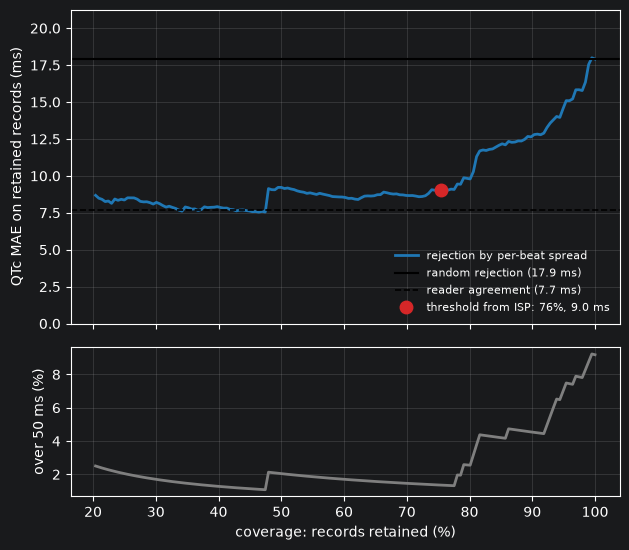

In [35]:
rand = np.array([np.abs(e_all[RNG.permutation(len(e_all))[:keep.sum()]]).mean()
                 for _ in range(2000)])
gain = np.abs(e_all).mean() - np.abs(e_keep).mean()
spread_all = G["spread"].values
diffs = np.empty(5000)
for i in range(5000):
    j = RNG.integers(0, len(e_all), len(e_all))
    eb, kb = e_all[j], spread_all[j] <= THR
    diffs[i] = (np.abs(eb).mean() - np.abs(eb[kb]).mean()
                if kb.sum() >= 10 else np.nan)
lo, hi = np.nanpercentile(diffs, [2.5, 97.5])
print(f"\nscore-based rejection : MAE {np.abs(e_keep).mean():.2f}")
print(f"random rejection      : MAE {rand.mean():.2f}")
print(f"gain {gain:+.2f} ms, 95% interval [{lo:+.2f}, {hi:+.2f}]  "
      f"{'ESTABLISHED' if lo > 0 else 'not established'}")
pd.DataFrame([{"gain": gain, "lo": lo, "hi": hi, "random": rand.mean(),
               "threshold": THR, "coverage": 100*keep.mean()}]).round(2).to_csv(
    RES_DIR/"step10_control.csv", index=False)

order  = np.argsort(spread_all); e_sort = e_all[order]; n = len(e_sort)
cov, mae, o50 = [], [], []
for k in range(40, n+1):
    a = np.abs(e_sort[:k])
    cov.append(100*k/n); mae.append(a.mean()); o50.append(100*(a > 50).mean())

fig, (ax, bx) = plt.subplots(2, 1, figsize=(6.4, 5.6), sharex=True,
                             gridspec_kw={"height_ratios": [2.1, 1]})
ax.plot(cov, mae, color="#1f77b4", lw=2, label="rejection by per-beat spread")
ax.axhline(np.abs(e_all).mean(), color="black", lw=1.5,
           label=f"random rejection ({np.abs(e_all).mean():.1f} ms)")
ax.axhline(FLOOR_MAE, color="black", ls="--", lw=1.2,
           label=f"reader agreement ({FLOOR_MAE:.1f} ms)")
ax.plot([100*keep.mean()], [np.abs(e_keep).mean()], "o", ms=9, color="#d62728",
        label=f"threshold from ISP: {100*keep.mean():.0f}%, "
              f"{np.abs(e_keep).mean():.1f} ms")
ax.set_ylabel("QTc MAE on retained records (ms)"); ax.set_ylim(0, max(mae)*1.18)
ax.legend(frameon=False, fontsize=8, loc="lower right"); ax.grid(alpha=.25)
bx.plot(cov, o50, color="#7f7f7f", lw=2)
bx.set_xlabel("coverage: records retained (%)"); bx.set_ylabel("over 50 ms (%)")
bx.grid(alpha=.25)
fig.tight_layout(); fig.savefig(FIG_DIR/"step11_selective_curve.png", dpi=200)
plt.show()

In [37]:
# import copy, numpy as np, pandas as pd, torch
# import torch.nn.functional as F
import copy
# comparison on loss function modification before refinement
P_CLS, QRS_CLS, T_CLS = 1, 2, 3
LAM     = 0.005          # weight on the interval term
SEED    = 42
OBJ_DEV = DEV            # same device as the rest of the run


# ---- differentiable boundary position -----------------------------------
def soft_edge(prob, anchor, half, rising, temp=0.05):
    """Sub-sample boundary, differentiable.
    """
    n = prob.shape[0]
    a, b = max(0, int(anchor) - half), min(n, int(anchor) + half + 1)
    if b - a < 3:
        return None
    seg = prob[a:b]
    d = seg[1:] - seg[:-1]
    d = d if rising else -d
    d = d / (d.max().detach() + 1e-6)
    w = torch.softmax(d / temp, dim=0)
    idx = torch.arange(a, b - 1, device=prob.device, dtype=prob.dtype) + 0.5
    return (w * idx).sum()


def true_beats(y, max_beats=99):
    """(QRS onset, T offset) pairs from one reference label sequence."""
    yn = y.detach().cpu().numpy()
    q = np.flatnonzero(np.diff((yn == QRS_CLS).astype(np.int8), prepend=0) == 1)
    t = np.flatnonzero(np.diff((yn == T_CLS).astype(np.int8), append=0) == -1)
    out = []
    for qq in q:
        nx = t[t > qq]
        if nx.size:
            out.append((int(qq), int(nx[0])))
        if len(out) >= max_beats:
            break
    return out


def pred_anchors(logits_i, max_beats=99):
    """The network's OWN boundaries, detached, used only to place windows.
    """
    lab = logits_i.argmax(0).detach().cpu().numpy()
    q = np.flatnonzero(np.diff((lab == QRS_CLS).astype(np.int8), prepend=0) == 1)
    t = np.flatnonzero(np.diff((lab == T_CLS).astype(np.int8), append=0) == -1)
    out = []
    for qq in q:
        nx = t[t > qq]
        if nx.size:
            out.append((int(qq), int(nx[0])))
        if len(out) >= max_beats:
            break
    return out


def interval_loss(logits, y, fs=500, half_ms=40, w_qt=1.0, w_pt=0.25,
                  tol_ms=150):
    """QT error in milliseconds, differentiable.
    """
    probs = torch.softmax(logits, dim=1)
    half = int(half_ms * fs / 1000)
    tol  = tol_ms * fs / 1000
    ms   = 1000.0 / fs
    tot, cnt = torch.zeros((), device=logits.device), 0
    for i in range(logits.shape[0]):
        truth = true_beats(y[i])
        if not truth:
            continue
        tq = np.array([a for a, _ in truth]); tt = np.array([b for _, b in truth])
        pq, pt = probs[i, QRS_CLS], probs[i, T_CLS]
        for q_a, t_a in pred_anchors(logits[i]):
            j = int(np.argmin(np.abs(tq - q_a)))
            if abs(tq[j] - q_a) > tol or abs(tt[j] - t_a) > tol:
                continue
            q_h = soft_edge(pq, q_a, half, rising=True)
            t_h = soft_edge(pt, t_a, half, rising=False)
            if q_h is None or t_h is None:
                continue
            e_qt = ((t_h - q_h) - float(tt[j] - tq[j])) * ms
            e_q  = (q_h - float(tq[j])) * ms
            e_t  = (t_h - float(tt[j])) * ms
            z = torch.zeros_like(e_qt)
            tot = tot + w_qt * F.smooth_l1_loss(e_qt, z, beta=5.0) \
                      + w_pt * F.smooth_l1_loss(e_q,  z, beta=5.0) \
                      + w_pt * F.smooth_l1_loss(e_t,  z, beta=5.0)
            cnt += 1
    return tot / max(cnt, 1)


def boundary_weight_map(y, fs=500, width_ms=40, peak=5.0):
    """Objective B: weight rises near every class transition."""
    w = torch.ones_like(y, dtype=torch.float32)
    half = max(1, int(width_ms * fs / 1000))
    changed = (y[:, 1:] != y[:, :-1]).float()
    changed = F.pad(changed.unsqueeze(1), (1, 0))
    k = torch.ones(1, 1, 2 * half + 1, device=y.device)
    near = F.conv1d(changed, k, padding=half).squeeze(1).clamp(0, 1)
    return w + (peak - 1.0) * near


# ---- one trainer, three modes -------------------------------------------
def train_obj(mode, name, epochs=None, batch=4, lr=1e-3, dev=None):
    """mode: 'ce' | 'bw' | 'interval'. Everything else identical."""
    epochs = epochs or EPOCHS
    dev = dev or OBJ_DEV
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = BeatSSLSeg().to(dev)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    dl_tr = torch.utils.data.DataLoader(SegDS12(isp_train), batch_size=batch, shuffle=True)
    dl_va = torch.utils.data.DataLoader(SegDS12(isp_val),   batch_size=batch)
    hist = {"ce": [], "iv": [], "val_f1": []}
    best, best_sd = -1.0, None

    for ep in range(epochs):
        model.train(); run_ce = run_iv = 0.0; nb = 0
        for x, y in dl_tr:
            x, y = x.to(dev), y.to(dev).long()
            logits = model(x)
            if mode == "bw":
                w  = boundary_weight_map(y, fs=500)
                ce = (F.cross_entropy(logits, y, reduction="none") * w).mean()
                iv = torch.zeros((), device=dev)
            else:
                ce = F.cross_entropy(logits, y)
                iv = interval_loss(logits, y) if mode == "interval" \
                     else torch.zeros((), device=dev)
            loss = ce + LAM * iv
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            run_ce += ce.item(); run_iv += float(iv); nb += 1

        model.eval(); inter = np.zeros(4); union = np.zeros(4)
        with torch.no_grad():
            for x, y in dl_va:
                x, y = x.to(dev), y.to(dev).long()
                pr = model(x).argmax(1)
                for c in range(4):
                    inter[c] += ((pr == c) & (y == c)).sum().item()
                    union[c] += ((pr == c).sum() + (y == c).sum()).item()
        f1 = float(np.mean(2 * inter[1:] / np.maximum(union[1:], 1)))
        hist["ce"].append(run_ce/nb); hist["iv"].append(run_iv/nb)
        hist["val_f1"].append(f1)
        if f1 > best:
            best, best_sd = f1, copy.deepcopy(model.state_dict())
        if ep % 5 == 0 or ep == epochs - 1:
            print(f"  {name} ep{ep:02d}  ce {run_ce/nb:.4f}  "
                  f"interval {run_iv/nb:7.2f} ms  valF1 {f1:.4f}")

    model.load_state_dict(best_sd)
    print(f"  -> best val F1 {best:.4f}")
    return model.eval(), hist, best


# ---- run the three ------------------------------------------------------
VARIANTS = [("A cross-entropy", "ce"),
            ("B boundary-weighted", "bw"),
            ("C interval-aware", "interval")]

OBJ, OBJ_HIST, OBJ_F1 = {}, {}, {}
for tag, mode in VARIANTS:
    print(f"\n===== {tag} =====")
    m, h, f1 = train_obj(mode, tag)
    OBJ[tag], OBJ_HIST[tag], OBJ_F1[tag] = m, h, f1
    torch.save(m.state_dict(), CKPT/f"obj_{mode}_s{SEED}.pt")


# ---- evaluate, with and without the refinement --------------------------
print("\n" + "="*74)
print("THREE OBJECTIVES ON UNSEEN DATA".center(74))
print("="*74)

rows = []
for tag, _ in VARIANTS:
    SEG["_obj"] = OBJ[tag]; SEG_PRED["_obj"] = SEG_PRED["beatssl"]
    for lbl, kw in (("no refinement", {}),
                    ("refined", dict(refine=MODE, clamp=CLAMP))):
        P, R = qtc_errors(ludb, "_obj", **kw)
        e = P - R; e = e[np.isfinite(e)]
        if not len(e):
            continue
        rows.append({"objective": tag, "refinement": lbl, "n": len(e),
                     "bias": e.mean(), "MAE": np.abs(e).mean(),
                     "SD": e.std(ddof=1),
                     "val F1": OBJ_F1[tag] if lbl == "no refinement" else np.nan})
SEG.pop("_obj", None); SEG_PRED.pop("_obj", None)

OBJT = pd.DataFrame(rows).round(2)
OBJT.to_csv(RES_DIR/"loss_comparison.csv", index=False)
print(OBJT.to_string(index=False))

piv = OBJT.pivot(index="objective", columns="refinement", values="MAE")
print("\nQTc MAE on LUDB (ms)\n")
print(piv.to_string())

A, B, C = [t for t, _ in VARIANTS]
c_vs_a = piv.loc[C, "no refinement"] - piv.loc[A, "no refinement"]
b_vs_a = piv.loc[B, "no refinement"] - piv.loc[A, "no refinement"]
ref_a  = piv.loc[A, "no refinement"] - piv.loc[A, "refined"]
ref_c  = piv.loc[C, "no refinement"] - piv.loc[C, "refined"]

print(f"""
  C vs A : {c_vs_a:+.2f} ms
  B vs A : {b_vs_a:+.2f} ms
        A {ref_a:+.2f}   C {ref_c:+.2f}""")




===== A cross-entropy =====
  A cross-entropy ep00  ce 0.5031  interval    0.00 ms  valF1 0.8656
  A cross-entropy ep05  ce 0.2471  interval    0.00 ms  valF1 0.8980
  A cross-entropy ep10  ce 0.2223  interval    0.00 ms  valF1 0.8942
  A cross-entropy ep15  ce 0.2113  interval    0.00 ms  valF1 0.9096
  A cross-entropy ep20  ce 0.1937  interval    0.00 ms  valF1 0.9030
  A cross-entropy ep25  ce 0.1898  interval    0.00 ms  valF1 0.9065
  A cross-entropy ep30  ce 0.1823  interval    0.00 ms  valF1 0.9089
  A cross-entropy ep35  ce 0.1697  interval    0.00 ms  valF1 0.9154
  A cross-entropy ep39  ce 0.1669  interval    0.00 ms  valF1 0.9114
  -> best val F1 0.9154

===== B boundary-weighted =====
  B boundary-weighted ep00  ce 1.7286  interval    0.00 ms  valF1 0.8554
  B boundary-weighted ep05  ce 0.9541  interval    0.00 ms  valF1 0.8927
  B boundary-weighted ep10  ce 0.8615  interval    0.00 ms  valF1 0.9021
  B boundary-weighted ep15  ce 0.8188  interval    0.00 ms  valF1 0.9072
 

/var/folders/_j/0bhqxk511s3cqdbky0t3b4g00000gn/T/ipykernel_21165/1148591565.py:134: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  run_ce += ce.item(); run_iv += float(iv); nb += 1


  C interval-aware ep00  ce 0.5926  interval  116.96 ms  valF1 0.8521
  C interval-aware ep05  ce 0.3016  interval   58.72 ms  valF1 0.8901
  C interval-aware ep10  ce 0.2683  interval   35.14 ms  valF1 0.8918
  C interval-aware ep15  ce 0.2413  interval   22.75 ms  valF1 0.9036
  C interval-aware ep20  ce 0.2224  interval   19.02 ms  valF1 0.8942
  C interval-aware ep25  ce 0.2174  interval   18.45 ms  valF1 0.9063
  C interval-aware ep30  ce 0.2148  interval   29.45 ms  valF1 0.9024
  C interval-aware ep35  ce 0.2034  interval   19.37 ms  valF1 0.9083
  C interval-aware ep39  ce 0.1997  interval   18.95 ms  valF1 0.9102
  -> best val F1 0.9102

                     THREE OBJECTIVES ON UNSEEN DATA                      
          objective    refinement   n   bias   MAE    SD  val F1
    A cross-entropy no refinement 195   7.93 30.81 47.90    0.92
    A cross-entropy       refined 195  -9.36 21.12 44.68     NaN
B boundary-weighted no refinement 195   3.09 32.72 54.98    0.91
B boundary

In [38]:

BEST_MODE, BEST_CLAMP = "both", 20

# ---- LUDB, the unseen database -----------------------------------------
f_fin, q_fin, df_fin = evaluate_seg(ludb, SEG, name="LUDB external",
                                    refine=BEST_MODE, max_shift_ms=BEST_CLAMP)
print(q_fin.to_string(index=False))
df_fin.to_csv(RES_DIR/"final_ludb.csv", index=False)
q_fin.to_csv(RES_DIR/"q_final_ludb.csv", index=False)

# ---- ISP held out, the missing half ---
f_isp, q_isp, df_isp = evaluate_seg(isp_test, SEG, name="ISP internal",
                                    refine=None, max_shift_ms=0)
print("\n" + q_isp.to_string(index=False))
df_isp.to_csv(RES_DIR/"final_isp.csv", index=False)
q_isp.to_csv(RES_DIR/"q_final_isp.csv", index=False)


def boot_ci(err, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    e = np.asarray(err, float)
    e = e[np.isfinite(e)]                      # drop records with no reference
    if len(e) < 5:
        return np.nan, np.nan, np.nan
    s = np.abs(e[rng.integers(0, len(e), (n, len(e)))]).mean(1)
    return np.abs(e).mean(), *np.percentile(s, [2.5, 97.5])


R_FINAL = {"LUDB external (refined)": df_fin, "ISP internal (raw)": df_isp}
METHODS = ["dwt", "cwt", "unet", "beatssl", "physiowave", "qtcnet"]

rows = []
for ds, d in R_FINAL.items():
    print(f"\n=== {ds} — MAE with bootstrap 95% CI ===")
    for m in METHODS:
        if m not in d.columns:
            print(f"  {m:<11} not in this frame"); continue
        p = d[[m, "gt"]].dropna()
        if len(p) < 5:
            print(f"  {m:<11} only {len(p)} usable records"); continue
        mae, lo, hi = boot_ci((p[m] - p["gt"]).values)
        print(f"  {m:<11} {mae:5.1f}  [{lo:5.1f}, {hi:5.1f}]  n={len(p)}")
        rows.append({"data": ds, "method": m, "n": len(p),
                     "MAE": mae, "lo": lo, "hi": hi})

pd.DataFrame(rows).round(2).to_csv(RES_DIR/"bootstrap_ci.csv", index=False)


# ---- the comparison-----------------------
d = df_fin
avail = [m for m in METHODS if m in d.columns]
maes = {m: np.abs(d[[m, "gt"]].dropna().pipe(lambda p: p[m]-p["gt"])).mean()
        for m in avail}
best = min(maes, key=maes.get)

rng = np.random.default_rng(0)
for m in avail:
    if m == best:
        continue
    p = d[[m, best, "gt"]].dropna()           # records BOTH methods answered
    if len(p) < 20:
        continue
    em = (p[m] - p["gt"]).values
    e0 = (p[best] - p["gt"]).values
    diffs = np.empty(5000)
    for i in range(5000):
        j = rng.integers(0, len(p), len(p))
        diffs[i] = np.abs(em[j]).mean() - np.abs(e0[j]).mean()
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    obs = np.abs(em).mean() - np.abs(e0).mean()
    print(f"  {m:<11} vs {best}: {obs:+6.2f} ms  [{lo:+6.2f}, {hi:+6.2f}]  "
          f"{'established' if lo > 0 else 'not established'}  n={len(p)}")

#Bland-Altman
plt.tight_layout()
plt.savefig(FIG_DIR/"bland_altman.png", dpi=200, bbox_inches="tight")
plt.show()


[LUDB external] 197 records | gt 197 | dwt 194 | cwt 146 | unet 196 | beatssl 196 | physiowave 196 | qtcnet 197
      dataset refine     method   n  coverage_%   bias    SD   MAE  median_AE  p90_AE  corr  IEC
LUDB external   both     qtcnet 197      100.00  -7.61 28.65 16.45       9.47   34.43  0.69 PASS
LUDB external   both    beatssl 196       99.49  -8.97 35.85 17.91       7.28   43.02  0.51 FAIL
LUDB external   both       unet 196       99.49  -4.72 37.93 18.34       8.36   44.36  0.51 FAIL
LUDB external   both physiowave 196       99.49 -10.21 52.86 25.32       8.56   67.99  0.19 FAIL
LUDB external   both        cwt 146       74.11  31.53 58.79 46.03      30.42   76.41  0.50 FAIL
LUDB external   both        dwt 194       98.48  21.40 68.31 53.34      46.22  122.03  0.22 FAIL
[ISP internal] 94 records | gt 94 | dwt 94 | cwt 86 | unet 93 | beatssl 94 | physiowave 94 | qtcnet 94

     dataset refine     method  n  coverage_%   bias    SD   MAE  median_AE  p90_AE  corr  IEC
ISP intern

<Figure size 640x480 with 0 Axes>

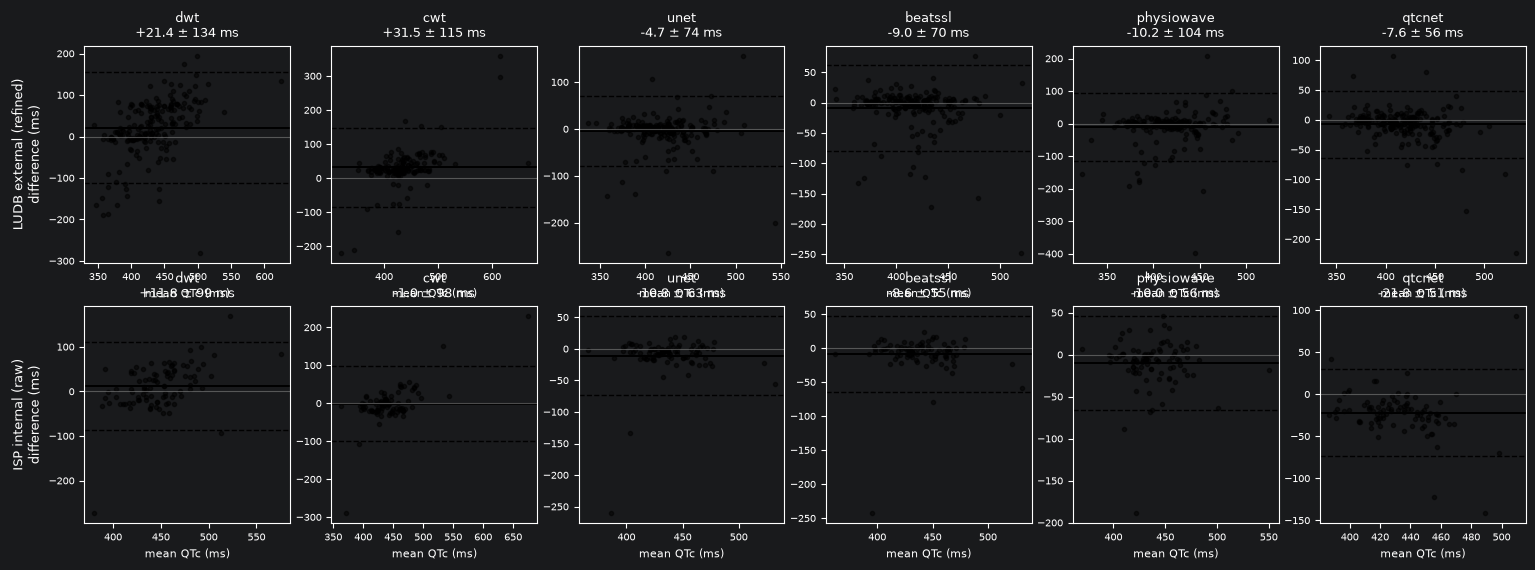

In [39]:
fig, axes = plt.subplots(len(R_FINAL), len(METHODS),
                         figsize=(3.1*len(METHODS), 3.1*len(R_FINAL)),
                         squeeze=False)

for i, (ds, d) in enumerate(R_FINAL.items()):
    for j, m in enumerate(METHODS):
        a = axes[i][j]
        if m not in d.columns:
            a.axis("off"); continue
        p = d[[m, "gt"]].dropna()
        if len(p) < 3:
            a.axis("off"); continue
        mean = (p[m] + p["gt"]) / 2
        diff =  p[m] - p["gt"]
        b, s = diff.mean(), diff.std(ddof=1)
        a.scatter(mean, diff, s=9, alpha=.5, color="black")
        a.axhline(b, color="black", lw=1.4)
        a.axhline(b + 1.96*s, color="black", ls="--", lw=1)
        a.axhline(b - 1.96*s, color="black", ls="--", lw=1)
        a.axhline(0, color="grey", lw=.8, alpha=.6)
        a.set_title(f"{m}\n{b:+.1f} $\\pm$ {1.96*s:.0f} ms", fontsize=9)
        if j == 0:
            a.set_ylabel(f"{ds}\ndifference (ms)", fontsize=9)
        a.set_xlabel("mean QTc (ms)", fontsize=8)
        a.tick_params(labelsize=7)


In [40]:
P0, R0 = qtc_errors(ludb, MODEL)
P1, R1 = qtc_errors(ludb, MODEL, refine=MODE, clamp=CLAMP)
s0, s1 = summarise(P0, R0), summarise(P1, R1)
FINAL = pd.DataFrame([
    {"stage": f"{MODEL} as trained",   "coverage %": 100.0, **s0},
    {"stage": "+ T-offset refinement", "coverage %": 100.0, **s1},
    {"stage": "+ rejection gate", "coverage %": 100*keep.mean(),
     "n": int(keep.sum()), "bias": e_keep.mean(), "MAE": np.abs(e_keep).mean(),
     "median AE": np.median(np.abs(e_keep)), "SD": e_keep.std(ddof=1),
     "P90": np.percentile(np.abs(e_keep), 90),
     "over50": 100*(np.abs(e_keep) > 50).mean(),
     "within15": 100*(np.abs(e_keep) <= 15).mean(),
     "usable": np.nan, "slope": np.nan, "sens": np.nan, "spec": np.nan,
     "acc": np.nan, "MAE/floor": np.abs(e_keep).mean()/FLOOR_MAE},
])[["stage","coverage %","n","bias","MAE","SD","P90","over50","within15",
    "MAE/floor"]].round(2)
FINAL.to_csv(RES_DIR/"step12_final.csv", index=False)
print("\n" + FINAL.to_string(index=False))


                stage  coverage %   n  bias   MAE    SD   P90  over50  within15  MAE/floor
   beatssl as trained      100.00 196  6.36 27.44 42.02 45.09    9.18     31.63       3.58
+ T-offset refinement      100.00 196 -8.97 17.91 35.85 43.02    9.18     72.96       2.34
     + rejection gate       75.51 148 -1.05  9.02 17.32 17.87    1.35     85.81       1.18


In [41]:
plt.style.use("default")
for _k in ("text.color", "axes.labelcolor", "axes.titlecolor", "axes.edgecolor",
           "xtick.color", "ytick.color", "xtick.labelcolor", "ytick.labelcolor"):
    matplotlib.rcParams[_k] = "black"
matplotlib.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "font.size": 10,
    "axes.grid": True, "grid.color": "0.88", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "hatch.linewidth": 0.8, "patch.edgecolor": "black",
})

STYLE = {"unet":       dict(fc="white", mk="o"),
         "beatssl":    dict(fc="0.62",  mk="s"),
         "physiowave": dict(fc="0.30",  mk="^")}
NAME  = {"unet": "U-Net", "beatssl": "BeatSSL", "physiowave": "PhysioWave"}
ORDER = ("unet", "beatssl", "physiowave")
R, F  = Path(RES_DIR), Path(FIG_DIR)

def load(n):
    p = R/n
    if not p.exists(): print(f"  skipped: {n} not found"); return None
    return pd.read_csv(p)

def save(fig, n):
    fig.tight_layout(); fig.savefig(F/n, dpi=300); plt.show(); print(f"  wrote {n}")




Figure 1 — training against validation, one panel per model


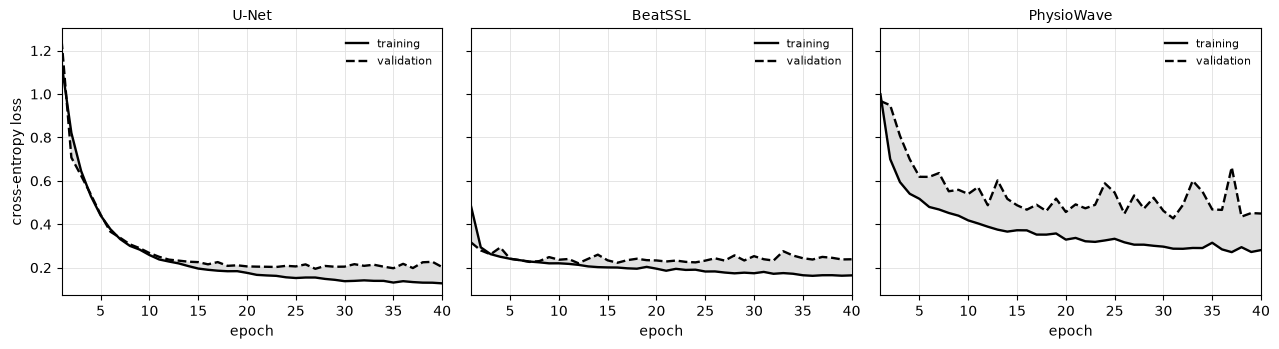

  wrote fig_1_curves.png

Figure 2 — which setting wins on each measure


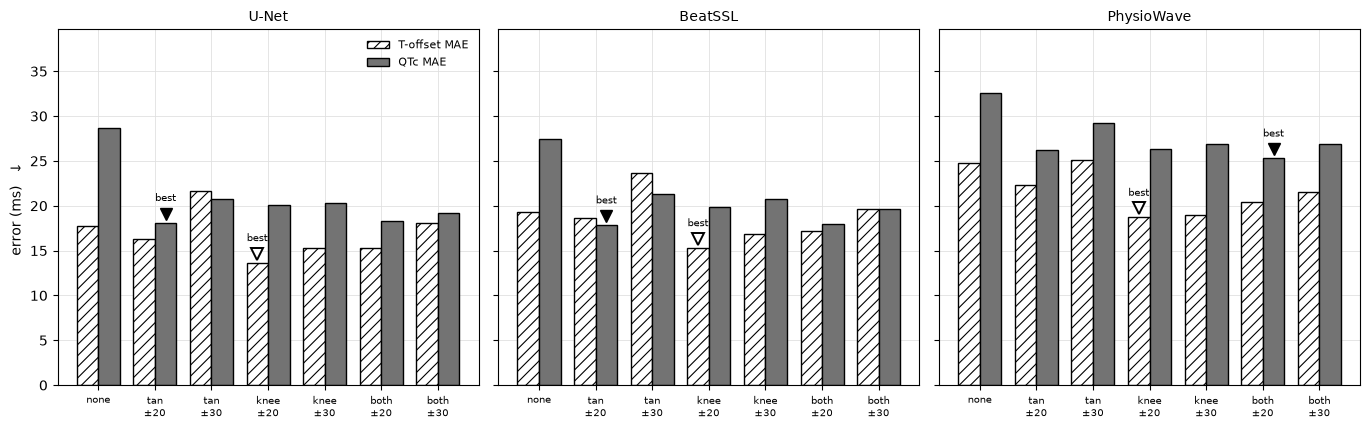

  wrote fig_2_dissociation.png

Figure 3 — helped on one database, harmed on the other


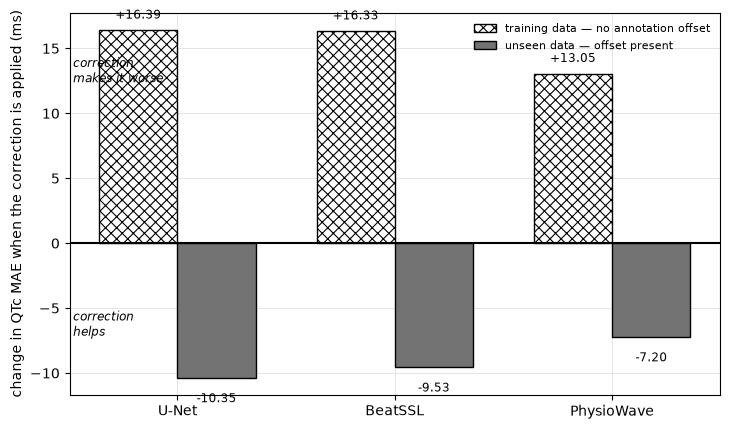

  wrote fig_3_harm.png

Figure 4 — before against after


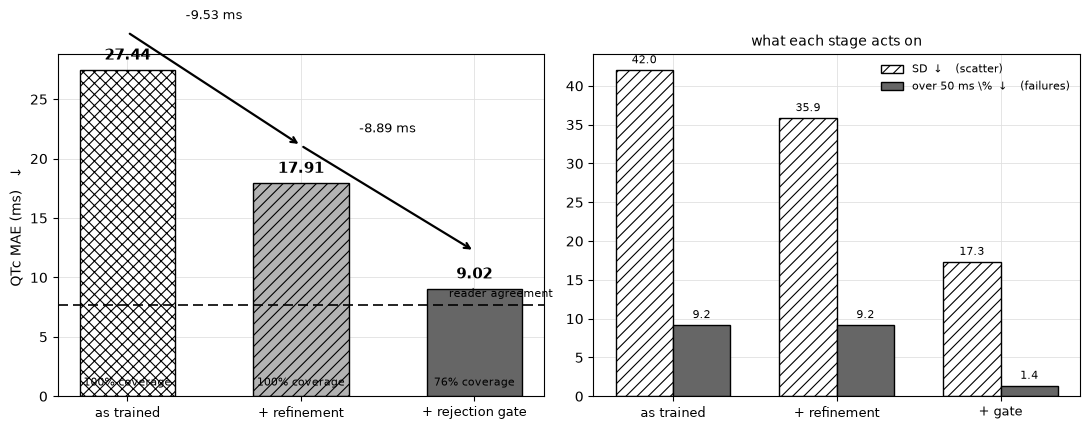

  wrote fig_4_waterfall.png


In [42]:

# =========================================================================
print("\nFigure 1 — training against validation, one panel per model")
# Solid training, dashed validation, shaded band between them. Nothing else.
# =========================================================================
try:
    ms = [m for m in ORDER if m in SEG_HIST]
    if not ms:
        raise KeyError("SEG_HIST empty — models were restored, not trained")
    fig, axes = plt.subplots(1, len(ms), figsize=(4.3*len(ms), 3.6), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, m in zip(axes, ms):
        h  = SEG_HIST[m]
        ep = np.arange(1, len(h["train_loss"]) + 1)
        tr, va = np.array(h["train_loss"]), np.array(h["val_loss"])
        ax.fill_between(ep, tr, va, facecolor="0.88", edgecolor="none")
        ax.plot(ep, tr, color="black", lw=1.7, ls="-",  label="training")
        ax.plot(ep, va, color="black", lw=1.7, ls="--", label="validation")
        ax.set_title(NAME[m], fontsize=10)
        ax.set_xlabel("epoch")
        ax.set_xlim(1, len(ep))
        ax.legend(frameon=False, fontsize=8)
    axes[0].set_ylabel("cross-entropy loss")
    save(fig, "fig_1_curves.png")
except Exception as e:
    print(f"  skipped ({e}). Needs SEG_HIST, so RESTORE must be False.")


# =========================================================================
print("\nFigure 2 — which setting wins on each measure")
# The clearest possible form of the central claim: two bars per setting,
# one panel per model, with the winner of each series marked. If the two
# markers sit over different bars, the measures disagree.
# =========================================================================
d = load("step3_ablation.csv")
if d is not None and "Toff MAE" in d.columns:
    SHORT = {"none": "none", "tangent +/-20": "tan\n$\\pm$20",
             "tangent +/-30": "tan\n$\\pm$30", "knee +/-20": "knee\n$\\pm$20",
             "knee +/-30": "knee\n$\\pm$30", "both +/-20": "both\n$\\pm$20",
             "both +/-30": "both\n$\\pm$30"}
    ms = [m for m in ORDER if m in set(d.model)]
    fig, axes = plt.subplots(1, len(ms), figsize=(4.6*len(ms), 4.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, m in zip(axes, ms):
        s_ = d[d.model == m].reset_index(drop=True)
        x  = np.arange(len(s_)); w = 0.38
        ax.bar(x - w/2, s_["Toff MAE"], w, facecolor="white",
               edgecolor="black", hatch="///", label="T-offset MAE")
        ax.bar(x + w/2, s_["QTc MAE"],  w, facecolor="0.45",
               edgecolor="black", label="QTc MAE")

        it = int(s_["Toff MAE"].idxmin())
        iq = int(s_["QTc MAE"].idxmin())
        top = max(s_["Toff MAE"].max(), s_["QTc MAE"].max())
        ax.plot([it - w/2], [s_["Toff MAE"][it] + 1.0], marker="v", ms=9,
                mfc="white", mec="black", mew=1.4, clip_on=False)
        ax.plot([iq + w/2], [s_["QTc MAE"][iq] + 1.0], marker="v", ms=9,
                mfc="black", mec="black", clip_on=False)
        ax.text(it - w/2, s_["Toff MAE"][it] + 2.4, "best", ha="center",
                fontsize=7.5)
        ax.text(iq + w/2, s_["QTc MAE"][iq] + 2.4, "best", ha="center",
                fontsize=7.5)

        ax.set_xticks(x)
        ax.set_xticklabels([SHORT.get(v, v) for v in s_["setting"]], fontsize=7.5)
        ax.set_title(NAME[m], fontsize=10)
        ax.set_ylim(0, top*1.22)
    axes[0].set_ylabel("error (ms)  $\\downarrow$")
    axes[0].legend(frameon=False, fontsize=8, loc="upper right")
    save(fig, "fig_2_dissociation.png")
elif d is not None:
    print("  step3_ablation.csv has no 'Toff MAE' column — re-run STEP 8.")


# =========================================================================
print("\nFigure 3 — helped on one database, harmed on the other")
# The strongest single piece of evidence in Chapter 7.
# =========================================================================
d = load("step7_isp_harm.csv")
if d is not None:
    piv = d.pivot(index="model", columns="data", values="change")
    piv = piv.reindex([m for m in ORDER if m in piv.index])
    x = np.arange(len(piv)); w = 0.36
    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    ax.bar(x - w/2, piv["ISP held out"], w, facecolor="white",
           edgecolor="black", hatch="xxx",
           label="training data — no annotation offset")
    ax.bar(x + w/2, piv["LUDB unseen"], w, facecolor="0.45",
           edgecolor="black", label="unseen data — offset present")
    ax.axhline(0, color="black", lw=1.5)
    for i, m in enumerate(piv.index):
        for dx, col in ((-w/2, "ISP held out"), (w/2, "LUDB unseen")):
            v = piv.loc[m, col]
            ax.text(i + dx, v + (0.9 if v >= 0 else -1.9), f"{v:+.2f}",
                    ha="center", fontsize=8.5)
    lo, hi = piv.values.min(), piv.values.max()
    ax.text(-0.48, hi*0.88, "correction\nmakes it worse",
            fontsize=8.5, style="italic", va="top")
    ax.text(-0.48, lo*0.72, "correction\nhelps", fontsize=8.5,
            style="italic", va="bottom")
    ax.set_xticks(x); ax.set_xticklabels([NAME[m] for m in piv.index])
    ax.set_ylabel("change in QTc MAE when the correction is applied (ms)")
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    save(fig, "fig_3_harm.png")


# =========================================================================
print("\nFigure 4 — before against after")
# Left: the error at each stage. Right: what each stage acts on.
# =========================================================================
d = load("step12_final.csv")
if d is not None:
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4.4))
    x = np.arange(len(d))
    fills   = ["white", "0.70", "0.40"][:len(d)]
    hatches = ["xxx", "///", ""][:len(d)]
    bars = ax.bar(x, d["MAE"], 0.55, facecolor="white", edgecolor="black")
    for b, fc, hh in zip(bars, fills, hatches):
        b.set_facecolor(fc); b.set_hatch(hh)
    for i, r in d.iterrows():
        ax.text(i, r["MAE"] + 0.9, f"{r['MAE']:.2f}", ha="center",
                fontsize=11, fontweight="bold")
        ax.text(i, 0.9, f"{r['coverage %']:.0f}% coverage", ha="center", fontsize=8)
    for i in range(len(d) - 1):
        top = max(d["MAE"].iloc[i], d["MAE"].iloc[i+1])
        ax.annotate("", xy=(i+1, d["MAE"].iloc[i+1] + 3.2),
                    xytext=(i, d["MAE"].iloc[i] + 3.2),
                    arrowprops=dict(arrowstyle="->", color="black", lw=1.6))
        ax.text(i + 0.5, top + 4.3,
                f"{d['MAE'].iloc[i+1]-d['MAE'].iloc[i]:+.2f} ms",
                ha="center", fontsize=9)
    try:
        ax.axhline(FLOOR_MAE, color="black", ls=(0, (6, 3)), lw=1.2)
        ax.text(len(d)-0.55, FLOOR_MAE + 0.7, "reader agreement",
                fontsize=8, ha="right")
    except Exception:
        pass
    ax.set_xticks(x)
    ax.set_xticklabels(["as trained", "+ refinement", "+ rejection gate"][:len(d)],
                       fontsize=9)
    ax.set_ylabel("QTc MAE (ms)  $\\downarrow$")

    w = 0.35
    bx.bar(x - w/2, d["SD"], w, facecolor="white", edgecolor="black",
           hatch="///", label="SD $\\downarrow$   (scatter)")
    bx.bar(x + w/2, d["over50"], w, facecolor="0.40", edgecolor="black",
           label="over 50 ms \\% $\\downarrow$   (failures)")
    for i, r in d.iterrows():
        bx.text(i - w/2, r["SD"] + 0.9, f"{r['SD']:.1f}", ha="center", fontsize=8)
        bx.text(i + w/2, r["over50"] + 0.9, f"{r['over50']:.1f}",
                ha="center", fontsize=8)
    bx.set_xticks(x)
    bx.set_xticklabels(["as trained", "+ refinement", "+ gate"][:len(d)], fontsize=9)
    bx.set_title("what each stage acts on", fontsize=10)
    bx.legend(frameon=False, fontsize=8)
    save(fig, "fig_4_waterfall.png")


In [43]:
from scipy import stats
FORMS = ("bazett", "fridericia", "framingham", "hodges", "rautaharju")


def _rows(recs, tag):
    """Reference QT, RR and QTc per record, from the human marks alone."""
    out = []
    for rec in recs:
        try:
            g_on, g_off = gt_fiducials(rec)
            rp = r_peaks(rec)
        except Exception:
            continue
        if len(g_on) == 0 or len(rp) < 2:
            continue
        fs = rec["fs"]
        rr = float(np.median(np.diff(rp)) / fs)
        if not np.isfinite(rr) or rr <= 0:
            continue
        qt = (np.asarray(g_off, float) - np.asarray(g_on, float)) / fs
        qt = qt[(qt > 0.20) & (qt < 0.70)]
        if len(qt) == 0:
            continue
        row = {"db": tag, "id": rec["id"],
               "QT": 1000.0 * float(np.median(qt)),
               "RR": rr, "HR": 60.0 / rr}
        for f in FORMS:
            row[f] = qtc(g_on, g_off, rp, fs, f)
        out.append(row)
    return out


D = pd.DataFrame(_rows(isp, "ISP") + _rows(ludb, "LUDB"))
D = D[np.isfinite(D["QT"]) & np.isfinite(D["RR"])].reset_index(drop=True)
A = D[D.db == "ISP"]
B = D[D.db == "LUDB"]
print(f"ISP {len(A)} records, LUDB {len(B)} records\n")


#raw QT, before any correction
print("="*70)
print("TEST 1  raw QT interval, no correction applied")
print("="*70)
qt_gap = A["QT"].mean() - B["QT"].mean()
t, p = stats.ttest_ind(A["QT"], B["QT"], equal_var=False)
print(f"  ISP  mean QT {A['QT'].mean():7.2f} ms  (SD {A['QT'].std():.2f})")
print(f"  LUDB mean QT {B['QT'].mean():7.2f} ms  (SD {B['QT'].std():.2f})")
print(f"  raw QT gap   {qt_gap:+7.2f} ms   p = {p:.2e}")


print("\n" + "="*70)
print("TEST 2  heart rate distributions")
print("="*70)
ks, pks = stats.ks_2samp(A["HR"], B["HR"])
print(f"  ISP  HR {A['HR'].mean():6.2f} +/- {A['HR'].std():5.2f} bpm"
      f"   median {A['HR'].median():.2f}")
print(f"  LUDB HR {B['HR'].mean():6.2f} +/- {B['HR'].std():5.2f} bpm"
      f"   median {B['HR'].median():.2f}")
print(f"  KS statistic {ks:.3f}, p = {pks:.2e}")


# the gap under every correction formula
print("\n" + "="*70)
print("TEST 3  the gap under each correction formula")
print("="*70)
rows = []
for f in FORMS:
    a, b = A[f].dropna(), B[f].dropna()
    rows.append({"formula": f, "ISP": a.mean(), "LUDB": b.mean(),
                 "gap": a.mean() - b.mean()})
T3 = pd.DataFrame(rows).round(2)
print(T3.to_string(index=False))
print(f"""
  Spread of the gap across formulae: {T3['gap'].max()-T3['gap'].min():.2f} ms.""")


#rate-matched comparison
print("\n" + "="*70)
print("TEST 4  offset within matched heart-rate bins")
print("="*70)
edges = np.percentile(D["HR"], [0, 20, 40, 60, 80, 100])
edges[-1] += 1e-6
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    a = A[(A.HR >= lo) & (A.HR < hi)]
    b = B[(B.HR >= lo) & (B.HR < hi)]
    if len(a) < 10 or len(b) < 10:
        continue
    rows.append({"HR bin": f"{lo:.0f}-{hi:.0f}", "n ISP": len(a), "n LUDB": len(b),
                 "QT gap": a["QT"].mean() - b["QT"].mean(),
                 "QTc gap": a["bazett"].mean() - b["bazett"].mean()})
T4 = pd.DataFrame(rows).round(2)
print(T4.to_string(index=False))
if len(T4):
    w = (T4["n ISP"] + T4["n LUDB"])
    pooled_qt  = float((T4["QT gap"]  * w).sum() / w.sum())
    pooled_qtc = float((T4["QTc gap"] * w).sum() / w.sum())
    print(f"\n  pooled within-bin QT  gap {pooled_qt:+.2f} ms")
    print(f"  pooled within-bin QTc gap {pooled_qtc:+.2f} ms")
D.to_csv(RES_DIR/"offset_confound.csv", index=False)
T3.to_csv(RES_DIR/"offset_by_formula.csv", index=False)
if len(T4): T4.to_csv(RES_DIR/"offset_by_hr_bin.csv", index=False)


ISP 461 records, LUDB 197 records

TEST 1  raw QT interval, no correction applied
  ISP  mean QT  396.87 ms  (SD 34.00)
  LUDB mean QT  398.35 ms  (SD 41.47)
  raw QT gap     -1.48 ms   p = 6.60e-01

TEST 2  heart rate distributions
  ISP  HR  76.09 +/- 14.54 bpm   median 73.62
  LUDB HR  68.35 +/- 14.29 bpm   median 65.22
  KS statistic 0.324, p = 2.33e-13

TEST 3  the gap under each correction formula
   formula    ISP   LUDB   gap
    bazett 442.54 421.35 21.18
fridericia 426.32 413.21 13.10
framingham 425.07 412.75 12.32
    hodges 425.24 413.61 11.63
rautaharju 430.56 415.58 14.98

  Spread of the gap across formulae: 9.55 ms.

TEST 4  offset within matched heart-rate bins
HR bin  n ISP  n LUDB  QT gap  QTc gap
 42-62     60      72    9.14     8.97
 62-68     83      48    9.77    11.64
 68-75    100      29   28.21    28.24
 75-84    111      23    9.08    11.65
84-143    107      25    5.76    12.36

  pooled within-bin QT  gap +12.31 ms
  pooled within-bin QTc gap +14.51 ms


In [44]:

FORMS_TEST = ("bazett", "fridericia", "hodges")     # worst, common, best
MODELS_T   = [m for m in ("unet", "beatssl", "physiowave") if m in SEG]
print(f"models: {MODELS_T}\nformulae: {FORMS_TEST}\n")


# ---- 1. does refinement still help on unseen data? ---------------------
print("="*74)
print("1  REFINEMENT GAIN ON LUDB, BY FORMULA")
print("="*74)
rows = []
for f in FORMS_TEST:
    for m in MODELS_T:
        P0, R0 = qtc_errors(ludb, m, formula=f)
        P1, R1 = qtc_errors(ludb, m, refine=MODE, clamp=CLAMP, formula=f)
        if not len(P0) or not len(P1):
            continue
        e0, e1 = P0 - R0, P1 - R1
        e0, e1 = e0[np.isfinite(e0)], e1[np.isfinite(e1)]
        rows.append({"formula": f, "model": m,
                     "bias none": e0.mean(), "MAE none": np.abs(e0).mean(),
                     "bias ref": e1.mean(),  "MAE ref": np.abs(e1).mean(),
                     "gain": np.abs(e0).mean() - np.abs(e1).mean()})
R1T = pd.DataFrame(rows).round(2)
print(R1T.to_string(index=False))

print("\n" + "="*74)
print("2  HARM REVERSAL BY FORMULA   <- the decisive test")
print("="*74)
rows = []
for f in FORMS_TEST:
    for m in MODELS_T:
        for tag, recs in (("ISP held out", isp_test), ("LUDB unseen", ludb)):
            P0, R0 = qtc_errors(recs, m, formula=f)
            P1, R1 = qtc_errors(recs, m, refine=MODE, clamp=CLAMP, formula=f)
            if not len(P0) or not len(P1):
                continue
            e0, e1 = P0 - R0, P1 - R1
            e0, e1 = e0[np.isfinite(e0)], e1[np.isfinite(e1)]
            rows.append({"formula": f, "model": m, "data": tag,
                         "without": np.abs(e0).mean(), "bias w/o": e0.mean(),
                         "with": np.abs(e1).mean(),    "bias with": e1.mean(),
                         "change": np.abs(e1).mean() - np.abs(e0).mean()})
R2T = pd.DataFrame(rows).round(2)
print(R2T.to_string(index=False))

print("\n  sign of 'change', by formula and model:")
piv = R2T.pivot_table(index=["formula", "model"], columns="data",
                      values="change").round(2)
print(piv.to_string())
ok = 0; tot = 0
for (f, m), r in piv.iterrows():
    isp_c, ludb_c = r.get("ISP held out", np.nan), r.get("LUDB unseen", np.nan)
    if np.isfinite(isp_c) and np.isfinite(ludb_c):
        tot += 1
        if isp_c > 0 and ludb_c < 0:
            ok += 1
print(f"\n  reversal holds in {ok} of {tot} formula-model combinations")


# ---- 3. constant shift against geometry, by formula --------------------
print("\n" + "="*74)
print("3  CONSTANT SHIFT AGAINST GEOMETRY, BY FORMULA")
print("="*74)
SWEEP = np.arange(-40, 11, 2)
rows = []
for f in FORMS_TEST:
    for m in MODELS_T:
        best, best_s = np.inf, None
        for s in SWEEP:
            P, R = qtc_errors(ludb, m, shift_ms=float(s), formula=f)
            if not len(P):
                continue
            e = P - R; e = e[np.isfinite(e)]
            if len(e) and np.abs(e).mean() < best:
                best, best_s = np.abs(e).mean(), int(s)
        Pg, Rg = qtc_errors(ludb, m, refine=MODE, clamp=CLAMP, formula=f)
        eg = Pg - Rg; eg = eg[np.isfinite(eg)]
        rows.append({"formula": f, "model": m, "constant": best,
                     "geometry": np.abs(eg).mean(),
                     "gap": abs(best - np.abs(eg).mean()),
                     "fitted shift": best_s})
R3T = pd.DataFrame(rows).round(2)
print(R3T.to_string(index=False))


for nm, df in (("robust1_refinement", R1T), ("robust2_harm", R2T),
               ("robust3_constant", R3T)):
    df.to_csv(RES_DIR/f"{nm}.csv", index=False)


models: ['unet', 'beatssl', 'physiowave']
formulae: ('bazett', 'fridericia', 'hodges')

1  REFINEMENT GAIN ON LUDB, BY FORMULA
   formula      model  bias none  MAE none  bias ref  MAE ref  gain
    bazett       unet      12.59     28.69     -4.72    18.34 10.35
    bazett    beatssl       6.36     27.44     -8.97    17.91  9.53
    bazett physiowave       6.76     32.52    -10.21    25.32  7.20
fridericia       unet      13.04     27.92     -4.03    17.12 10.79
fridericia    beatssl       6.92     26.32     -8.41    16.76  9.56
fridericia physiowave       7.62     31.61     -9.58    24.04  7.57
    hodges       unet      12.85     26.95     -3.69    16.57 10.39
    hodges    beatssl       6.92     25.63     -7.91    16.14  9.49
    hodges physiowave       7.15     30.45     -9.18    23.19  7.26

2  HARM REVERSAL BY FORMULA   <- the decisive test
   formula      model         data  without  bias w/o  with  bias with  change
    bazett       unet ISP held out    14.49    -10.80 30.88   